# Оглавление

- [Описание задачи](#описание-задачи)
- [Исходные данные](#исходные-данные)
   - [Семантика данных](#семантика-данных)
   - [Формулы прикладной области](#формулы-прикладной-области)
1.  [Предварительная обработка данных](#1-предварительная-обработка-данных)
      1. [Чтение и загрузка данных](#чтение-и-загрузка-данных)
      2. [Первичный анализ](#12-первичный-анализ-данных)
      3. [Разделение выборок на обучющую и тестовую](#13-разделение-выборки-на-обучающую-и-тестовую-выборки)
      4. [Кодирование категориальных признаков](#14-кодирование-категориальных-признаков)
      5. [Обработка вещественных признаков, заполнение пропусков](#15-обработка-вещественных-признаков-заполнение-пропусков)
      6. [Детекция выбросов и аномалий в данных](#16-детекция-выбросов-и-аномалий-в-данных)
      7. [Подведение итогов раздела 1](#17-подведение-итогов-раздела-1)
2. [Генерация новых признаков](#2-генерация-новых-признаков)
      1. [Корреляционный анализ входных признаков](#21-корреляционный-анализ-входных-признаков-построение-тепловых-карт-корреляции)
      2. [Исправление проблемы мультиколлинеарности](#22-исправление-проблемы-мультиколлинеарности-в-данных)
      3. [Скалирование данных](#23-скалирование-данных)
      4. [Подведение итогов раздела 2](#24-подведение-итогов-раздела-2)

# Описание задачи

**Цель проекта** - анализ данных характеристик магического портала, решение задачи регрессии.

**Целевой признак** - `Гармония бессмертия`

**Задачи**:
1.  **Предобработка данных**: очистка, обработка пропусков, преобразование типов данных, первичный анализ
2. **Генерация новых признаков**: 
    - дополнение данных новыми зависимостями
    - корреляционный анализ
    - скалирование данных
3. **Выбор моделей ML и обучение**: 
    - обоснование выбора моделей и метрик
    - обучение 
    - сравнение метрик
    - выбор лучшей модели



# Исходные данные

### Семантика данных

| Название признака | Тип данных | Описание | Ограничения значений |
|-------------------|------------|-----------|---------------------|
| **Вектор Мощи** | `float64` | Позиция магического механизма, управляющего интенсивностью перехода через портал | - |
| **Скорость перехода через портал** | `float64` | Скорость, с которой портал перемещает объект через пространство | > 0 |
| **Приток Силы Потока** | `float64` | Поток магической силы, текущий через ядро портала | > 0 |
| **Ритм магического ядра** | `float64` | Число оборотов магического ядра портала в минуту | > 0 |
| **Поток Энергий** | `float64` | Число оборотов генератора эфира, преобразующего внешнюю энергию в магическую | > 0 |
| **Сила Левого Потока** | `float64` | Мощность магического потока через левую сторону портала | > 0 |
| **Сила Правого Потока** | `float64` | Мощность магического потока через правую сторону портала | > 0 |
| **Пламя Стихий** | `float64` | Температура магической энергии из высокого магического источника портала (°C) | - |
| **Температура вдоха Истока** | `float64` | Температура воздуха, входящего в магический ускоритель портала (°C) | - |
| **Температура выдоха Истока** | `float64` | Температура воздуха, исходящего из магического ускорителя портала (°C) | - |
| **Приток давления Выдоха Истока** | `float64` | Давление магического потока на выходе из магического источника высокого давления | > 0 |
| **Давление вдоха Истока** | `float64` | Давление воздуха, входящего в магический ускоритель | > 0 |
| **Давление выдоха Истока** | `float64` | Давление воздуха, исходящего из магического ускорителя | > 0 |
| **Древний Ветер** | `float64` | Давление древней магической энергии, покидающей портал | > 0 |
| **Печать Чародея** | `float64` | Параметр управления магическим впрыском в сердце портала (%) | 0-100% |
| **Эмульсия Истока** | `float64` | Количество магического топлива, подпитывающего портал | > 0 |
| **Дыхание Истока** | `float64` | Коэффициент степени угасания магического ускорителя | - |
| **Гармония Бессмертия** | `float64` | Коэффициент состояния магического ядра портала и его стабильности | - |
| **Тип Вектора Мощи** | `category` | Метка типа позиции магического механизма | Категориальный |

---

###  Формулы прикладной области

####  **Допустимые формулы (новые признаки)**

| Название признака | Формула | Описание | Ограничения |
|-------------------|---------|-----------|-------------|
| **Совокупная мощность потоков** | `Сила_Левого_Потока + Сила_Правого_Потока` | Общая мощность левого и правого потоков | > 0 |
| **Суммарная сила всех потоков** | `Сила_Левого_Потока + Сила_Правого_Потока + Приток_Силы_Потока` | Полная мощность всех магических потоков | > 0 |
| **Общая сила ядра** | `Ритм_магического_ядра × Приток_Силы_Потока` | Показатель общей мощности ядра портала | > 0 |
| **Общее давление на выходе** | `Приток_давления_Выдоха_Истока + Давление_выдоха_Истока` | Суммарное давление на выходе системы | > 0 |
| **Магическая производительность** | `Скорость_перехода_через_портал ÷ Эмульсия_Истока` | Эффективность использования топлива для перехода | > 0 |
| **Эффективность ядра** | `Общая_сила_ядра ÷ Эмульсия_Истока` | Эффективность работы ядра относительно расхода топлива | > 0 |
| **Температурный градиент** | `Температура_выдоха_Истока - Температура_вдоха_Истока` | Разность температур на входе и выходе | - |
| **Баланс давлений** | `Давление_выдоха_Истока ÷ Давление_вдоха_Истока` | Отношение выходного давления к входному | ≠ 0 |
| **Магическая мощность** | `Вектор_мощи` * log2(`Пламя_Стихий`) + `Эмульсия_Истока` * sin(`Поток Энергий`) | Формула | - |

####  **Некорректные формулы**

Следующие формулы **нельзя использовать**, так как они:
- Используют целевую переменную (`Гармония Бессмертия`)
- Не имеют конкретного математического определения

| Формула | Причина запрета |
|---------|-----------------|
| **Степень износа** = `Дыхание_Истока ÷ Гармония_Бессмертия` | Использует целевую переменную |
| **Расхождение стабильности** = `\|Дыхание_Истока - Гармония_Бессмертия\|` | Использует целевую переменную |
| **Баланс угасания** = `(Дыхание_Истока - Гармония_Бессмертия) ÷ Скорость_перехода` | Использует целевую переменную |


# Информация о виртуальном окружении

### 1. Версия Python: 3.12.0

### 2. Список использемых библиотек

| Категория | Библиотека/Модуль | Псевдоним | Версия | Назначение |
|-----------|-------------------|-----------|--------|------------|
| **Системные** | `sys` | - | Python `3.12.0` | Системные функции Python |
| **Научные вычисления** | `numpy` | `np` | `1.24.3` | Математические операции с массивами |
| | `pandas` | `pd` | `2.0.3` | Анализ и обработка табличных данных |
| **Визуализация** | `matplotlib.pyplot` | `plt` | `3.7.2` | Построение графиков и диаграмм |
| | `seaborn` | `sns` | `0.12.2` | Статистическая визуализация |
| **Машинное обучение** | `sklearn.preprocessing` | - | `1.3.0` | Препроцессинг данных |
| | `sklearn.model_selection` | - | `1.3.0` | Разделение данных и валидация |
| **Анализ данных** | `missingno` | `msn` | `0.5.2` | Визуализация пропущенных значений |


### 3. Основные иморты

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import missingno as msn 
import warnings
warnings.filterwarnings('ignore')

### 4. Уставновление случайного сида

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# <font color = "#ed7c7cff">1. Предварительная обработка данных </font>

## 1.1. Чтение и загрузка данных 


In [3]:
#Загрузка данных, использование енкодера CP-1251 
df = pd.read_csv('portal_data.csv', sep='|', header=0, encoding='cp1251')
df.head()

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи,Номер пометки
0,1.138,1.54332,289.964,141.318158,6677.380,7.584,7.584,464.006,736,-,1.096,Не определено,5.947,-,7.137,0.082,0.95,0.975,Слабый,0
1,2.088,-,6960.180,144.111767,6828.469,28.204,28.204,635.401,736,581.658,1.331,1.394603,7.282,1.019,10.655,0.287,0.95,0.975,Слабый,1
2,3.144,4.6299600000000005,8379.229,145.220853,7111.811,60.358,60.358,606.002,736,-,1.389,Не определено,7.574,-,13.086,0.259,0.95,0.975,Ниже среднего,2
3,4.161,6.17328,14724.395,162.050156,7792.630,113.774,113.774,661.471,736,-,1.658,Не определено,9.007,-,18.109,0.358,0.95,0.975,Ниже среднего,3
4,5.140,7.7166,21636.432,201.513586,8494.777,175.306,175.306,731.494,736,645.642,2.078,Не определено,11.197,1.026,26.373,0.522,0.95,0.975,Выше среднего,4


## 1.2. Первичный анализ данных

In [4]:
#Описание данных
df.describe()

,Вектор Мощи,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Номер пометки
count,11934.000000,11934.000000,11934.000000,11934.000000,11934.000000,11934.000000,11934.000000,11934.0,11934.000000,11934.000000,11934.000000,11934.000000,11934.00000,11934.0000,11934.000000
mean,5.166667,27247.498685,223.711688,8200.947312,227.335768,227.335768,735.495446,736.0,2.352963,12.297123,33.641261,0.662440,0.97500,0.9875,5966.500000
std,2.626388,22148.613155,81.061874,1091.315507,200.495889,200.495889,173.680552,0.0,1.084770,5.337448,25.841363,0.507132,0.01472,0.0075,3445.193391
min,1.138000,253.547000,136.939406,6589.002000,5.304000,5.304000,442.364000,736.0,1.093000,5.828000,0.000000,0.068000,0.95000,0.9750,0.000000
25%,3.144000,8375.883750,145.220958,7058.324000,60.317000,60.317000,589.872750,736.0,1.389000,7.447250,13.677500,0.246000,0.96200,0.9810,2983.250000
50%,5.140000,21630.659000,201.514947,8482.081500,175.268000,175.268000,706.038000,736.0,2.083000,11.092000,25.276500,0.496000,0.97500,0.9875,5966.500000
75%,7.148000,39001.426750,280.447777,9132.606000,332.364750,332.364750,834.066250,736.0,2.981000,15.658000,44.552500,0.882000,0.98800,0.9940,8949.750000
max,9.300000,72784.872000,372.879926,9797.103000,645.249000,645.249000,1115.797000,736.0,4.560000,23.140000,92.556000,1.832000,1.00000,1.0000,11933.000000


#### Выводы:
- Большой разброс данных у признака `Приток силы потока`,
- Нулевое стандартное отклонение у `Темпаратура вдоха истока`
- Ненужный признак `Номер пометки`

In [5]:
#Информация о данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     11934 non-null  float64
 1   Скорость перехода через портал  11934 non-null  object 
 2   Приток Силы Потока              11934 non-null  float64
 3   Ритм магического ядра           11934 non-null  float64
 4   Поток Энергий                   11934 non-null  float64
 5   Сила Левого Потока              11934 non-null  float64
 6   Сила Правого Потока             11934 non-null  float64
 7   Пламя Стихий                    11934 non-null  float64
 8   Температура вдоха Истока        11934 non-null  int64  
 9   Температура выдоха Истока       11934 non-null  object 
 10  Приток давления Выдоха Истока   11934 non-null  float64
 11  Давление вдоха Истока           11934 non-null  object 
 12  Давление выдоха Истока          

In [6]:
# Приведение данных числовых столбцов numeric

numeric_columns = [
    'Вектор Мощи', 'Скорость перехода через портал', 'Приток Силы Потока',
    'Ритм магического ядра', 'Поток Энергий', 'Сила Левого Потока',
    'Сила Правого Потока', 'Пламя Стихий', 'Температура вдоха Истока',
    'Температура выдоха Истока', 'Приток давления Выдоха Истока',
    'Давление вдоха Истока', 'Давление выдоха Истока', 'Древний Ветер',
    'Печать Чародея', 'Эмульсия Истока', 'Дыхание Истока', 'Гармония Бессмертия'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
# Удаление дубликатов
df = df.drop_duplicates()

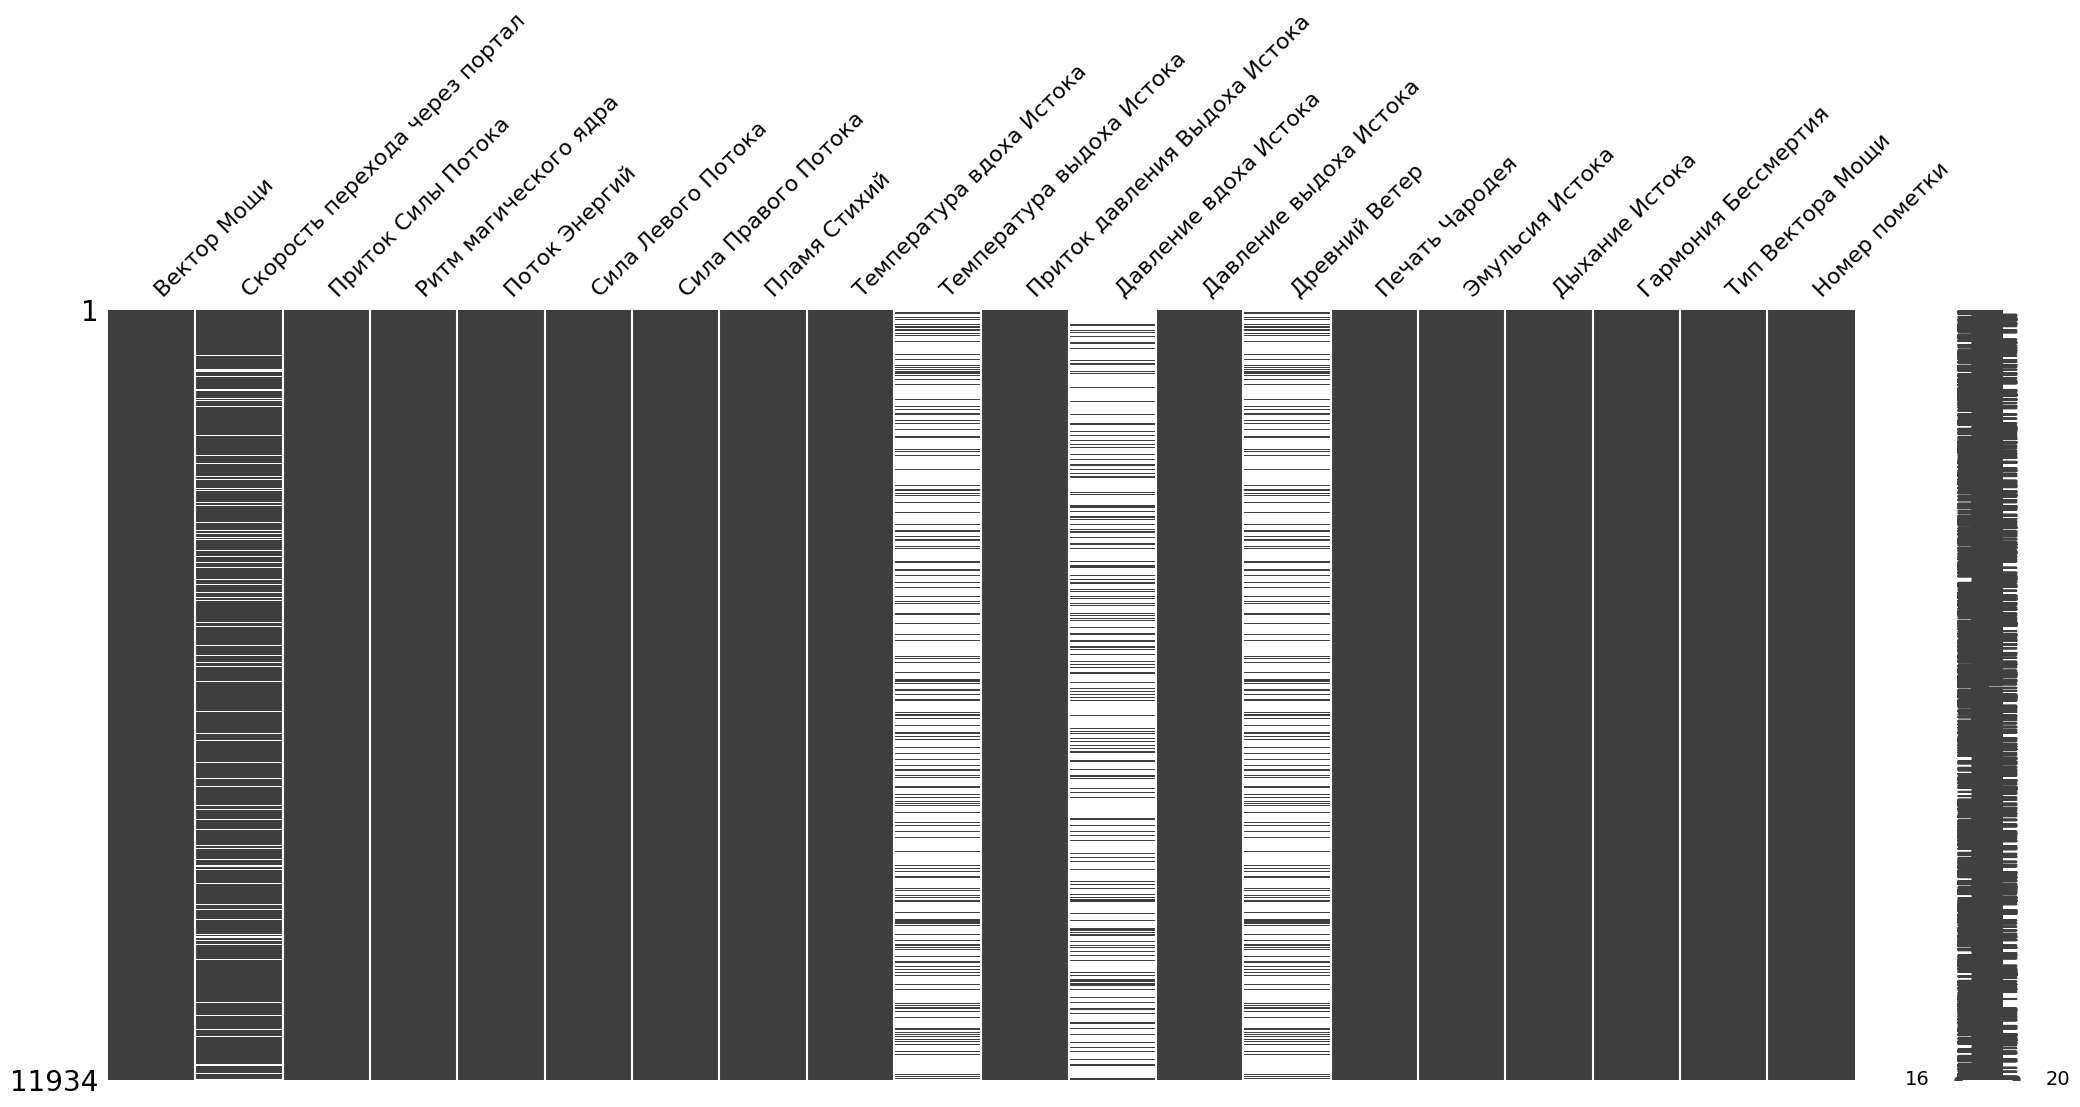

In [8]:
#Анализ пропусков
msn.matrix(df);

### Выводы
- Огромное количество пропусков в признаках: 
    1. `Температура выдоха истока`
    2. `Давление вдоха истока`
    3. `Древний Ветер`

In [9]:
#Удаление признаков
new_df = df.drop(columns=['Температура выдоха Истока', 'Давление вдоха Истока', 'Древний Ветер','Номер пометки', 'Температура вдоха Истока'])

In [10]:
new_df.head()

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи
0,1.138,1.54332,289.964,141.318158,6677.380,7.584,7.584,464.006,1.096,5.947,7.137,0.082,0.95,0.975,Слабый
1,2.088,NaN,6960.180,144.111767,6828.469,28.204,28.204,635.401,1.331,7.282,10.655,0.287,0.95,0.975,Слабый
2,3.144,4.62996,8379.229,145.220853,7111.811,60.358,60.358,606.002,1.389,7.574,13.086,0.259,0.95,0.975,Ниже среднего
3,4.161,6.17328,14724.395,162.050156,7792.630,113.774,113.774,661.471,1.658,9.007,18.109,0.358,0.95,0.975,Ниже среднего
4,5.140,7.71660,21636.432,201.513586,8494.777,175.306,175.306,731.494,2.078,11.197,26.373,0.522,0.95,0.975,Выше среднего


## 1.3. Разделение выборки на обучающую и тестовую выборки

In [11]:
#Разделение на выборки
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(new_df.drop(columns=['Гармония Бессмертия']), new_df['Гармония Бессмертия'], test_size=0.2,random_state=RANDOM_STATE)

In [12]:
#Сброс индексов
X_train, X_test, Y_train, Y_test = X_train.reset_index(drop=True), X_test.reset_index(drop = True), Y_train.reset_index(drop = True), Y_test.reset_index(drop = True)

In [13]:
#Объединение в обучающую выборку и тестовую (для дальнейшей обработки)
train_selection = pd.concat([X_train, Y_train], axis=1)
test_selection = pd.concat([X_test, Y_test], axis=1)

## 1.4 Кодирование категориальных признаков

<font color = "#d49bfaff"> Единственный категориальный признак: </font> `Тип вектора мощи`

In [14]:
#Анализ признака
train_selection['Тип Вектора Мощи'].unique()

array(['Выше среднего', 'Слабый', 'Сильный', 'Ниже среднего'],
      dtype=object)

Есть отношение порядка, следовательно, применим **Label** кодировщик

In [15]:
#Label - кодирование категориального признака (train_selection)

mapping = {'Ниже среднего': 1, 'Слабый': 0, 'Сильный': 3, 'Выше среднего': 2}
train_selection['Тип Вектора Мощи'] = train_selection['Тип Вектора Мощи'].map(mapping)

In [16]:
#Label - кодирование категориального признака (test_selection)

test_selection['Тип Вектора Мощи'] = test_selection['Тип Вектора Мощи'].map(mapping)

## 1.5. Обработка вещественных признаков (заполнение пропусков)

Единственный вещественный признак в датасете с пропущенными значениями: `Скорость перехода через портал`

#### Определим функцию KL - дивергенции

**KL дивергенция** (также известная как относительная энтропия) — это мера того, насколько одно вероятностное распределение отличается от другого эталонного распределения. 
- Чем меньше KL дивергенция, тем меньше распределения отличаются друг от друга

**Формула KL-дивергенции**

$$
D_{\text{KL}}(P \parallel Q) = \sum_{x \in \mathcal{X}} P(x) \log \frac{P(x)}{Q(x)}
$$

<font color = "#93eb98ff">Применение к нашей задаче</font>

 - понадобится для оценки качества **заполнения пропусков** различными методами

In [17]:
#KL - дивергенция
from scipy.special import rel_entr
def kl_divergence(p, q):
    hist_p, bin_edges = np.histogram(p, bins = 20, density=True)
    hist_q, _ = np.histogram(q, bins=bin_edges,density=True )

    hist_p /= np.sum(hist_p)
    hist_q /= np.sum(hist_q)
    return np.sum(rel_entr(hist_p, hist_q))

#### <font style =  "color: #e2e79bff">Статистический метод заполнения </font>

In [18]:
#Функция для заполнения пропусков столбца переданной статистикой
import matplotlib.pyplot as plt

def fill_gap(data : pd.DataFrame, stats : float, name_feat : str = 'Скорость перехода через портал'):

    p = data[name_feat].dropna()

    fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,5))

    ax1.hist(p, bins = 20)
    ax1.set_title("До заполнения пропусков")

    q = data[name_feat].fillna(stats)

    ax2.hist(q, bins = 20)
    ax2.set_title("После заполнения пропусков")

    plt.tight_layout()
    plt.show()

    print(f"KL - дивергенция {kl_divergence(p, q)}")

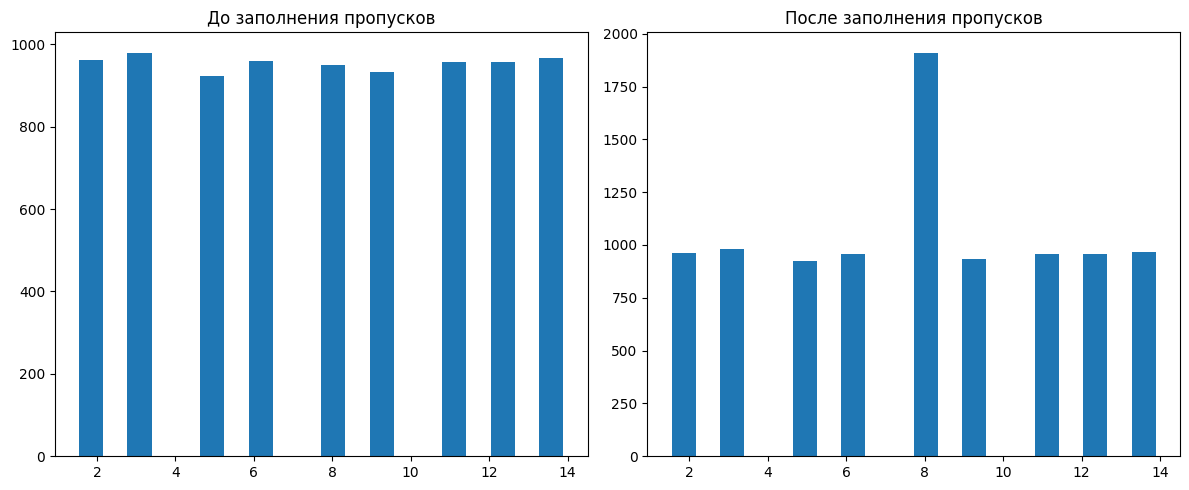

KL - дивергенция 0.02876183503190572


In [19]:
#Медиана
fill_gap(train_selection, train_selection['Скорость перехода через портал'].median())

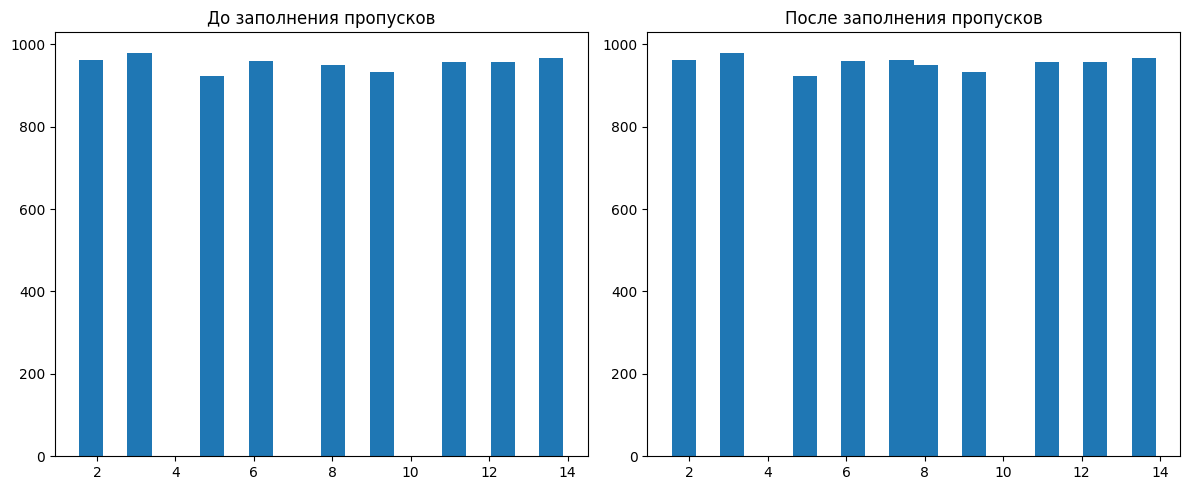

KL - дивергенция 0.10609399921352716


In [20]:
#Среднее
fill_gap(train_selection, train_selection['Скорость перехода через портал'].mean())

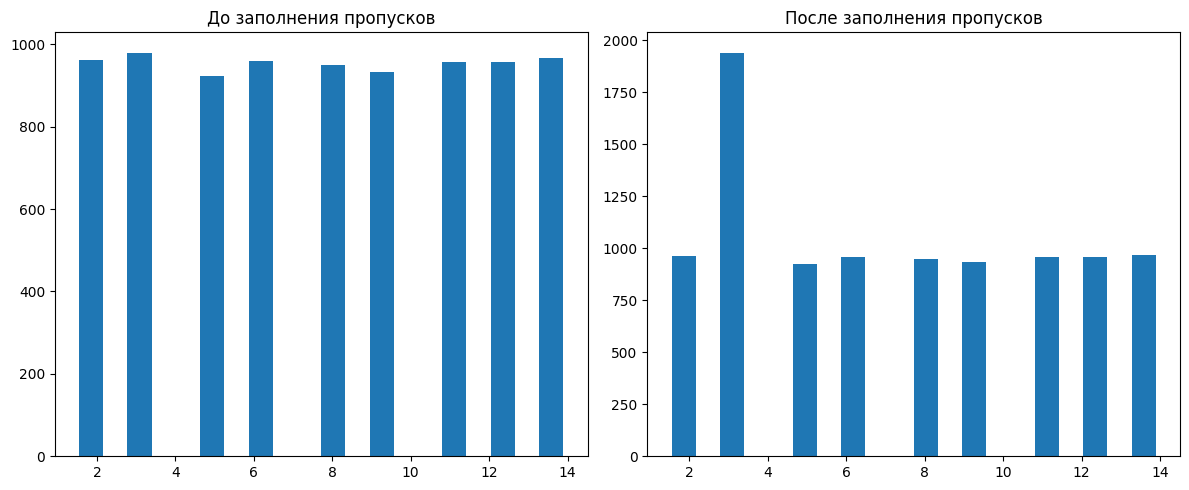

KL - дивергенция 0.028090517816566428


In [21]:
#Мода
fill_gap(train_selection, train_selection['Скорость перехода через портал'].mode().values[0])

##### Вывод:
**Лучшей статистикой** для заполнения пропусков является мода

#### <font color = "#83e5a2ff">Машинный метод </font>

In [22]:
#imports
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.ensemble import GradientBoostingRegressor

In [23]:
#Функция заполнения пропусков переданной моделью
def fill_ml(data : pd.DataFrame, model, name_feat : str = 'Скорость перехода через портал'):
    
    p = data[name_feat].dropna()

    fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,5))

    ax1.hist(p, bins = 20)
    ax1.set_title("До заполнения пропусков")

    q = pd.DataFrame(model.fit_transform(data), columns=data.columns)[name_feat]

    ax2.hist(q, bins = 20)
    ax2.set_title("После заполнения")

    print(f"KL - дивергенция {kl_divergence(p, q)}")

In [24]:
#IteratieImputer
iter_imp = IterativeImputer(
    max_iter=10, 
    random_state=50,
    estimator= GradientBoostingRegressor(n_estimators=100, random_state=42)
)

KL - дивергенция 0.012696562662431111


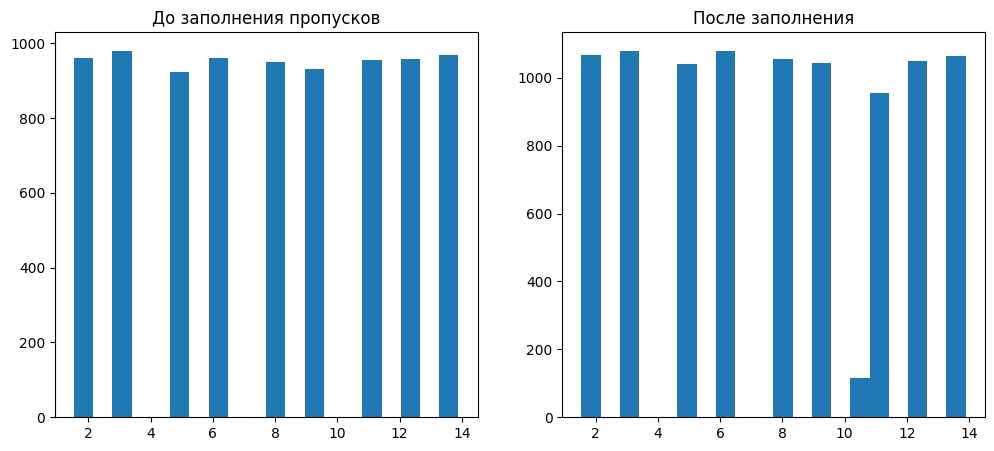

In [25]:
fill_ml(train_selection, iter_imp)

In [26]:
#KNNImputer
knn_imputer = KNNImputer(
    n_neighbors=5,         
    weights='uniform',     
    metric='nan_euclidean' 
)

KL - дивергенция 0.0006816073115444553


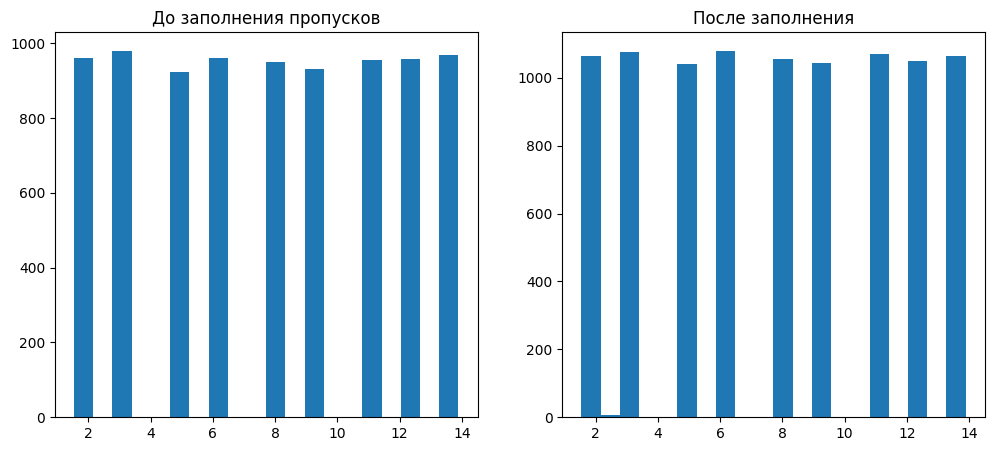

In [27]:
fill_ml(train_selection, knn_imputer)

### Вывод:
**Лучшую метрику KL дивергенции** показал машинный метод **KNNImputer**

### Применение метода заполнения пропуска к обучающей и тестовой выборкам

In [28]:
# Заполнение пропусков обучающей выборки 

name_feature  = 'Скорость перехода через портал'
columns = train_selection.columns
train_sel = pd.DataFrame(knn_imputer.transform(train_selection), columns=columns)

In [29]:
# Заполнение пропусков тестовой выборки

test_sel = pd.DataFrame(knn_imputer.transform(test_selection), columns=columns)

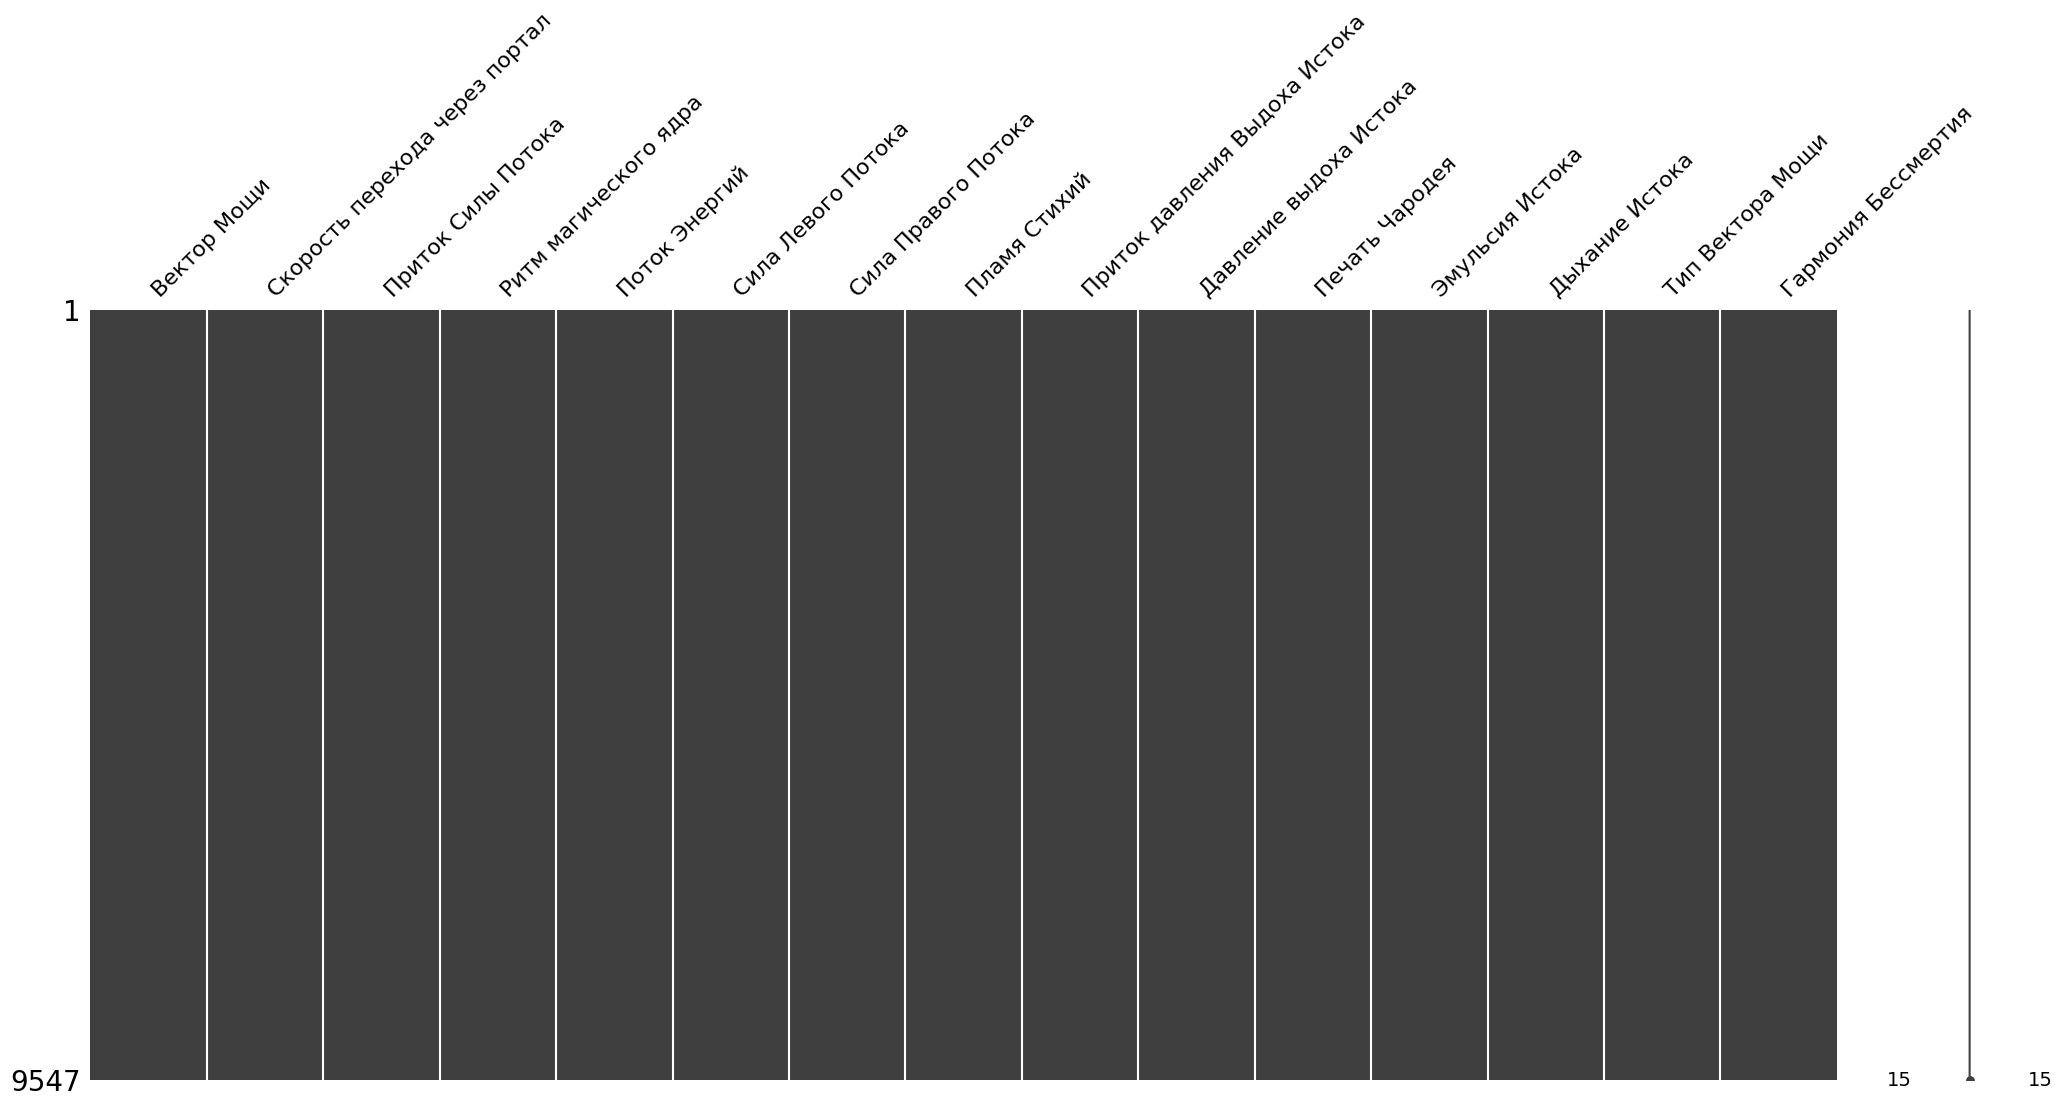

In [30]:
# Итоговая диаграмма пропусков обучающей выборки

msn.matrix(train_sel);

## 1.6. Детекция выбросов и аномалий в данных

### <font style = "color: #efca8fff"> Поиск выбросов </font>

In [31]:
# Функция отрисовки диаграммы boxplots для всех признаков

def plot_boxplots(selection:pd.DataFrame, name: str):
    fig, ax = plt.subplots(figsize=(40, 20)) 
    bp = ax.boxplot([selection[col].values for col in selection.columns], 
                labels=selection.columns,
                patch_artist=True)
    ax.set_title(f'Boxplots всех признаков. {name}', fontsize=16, fontweight='bold')
    ax.set_ylabel('Значения', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')

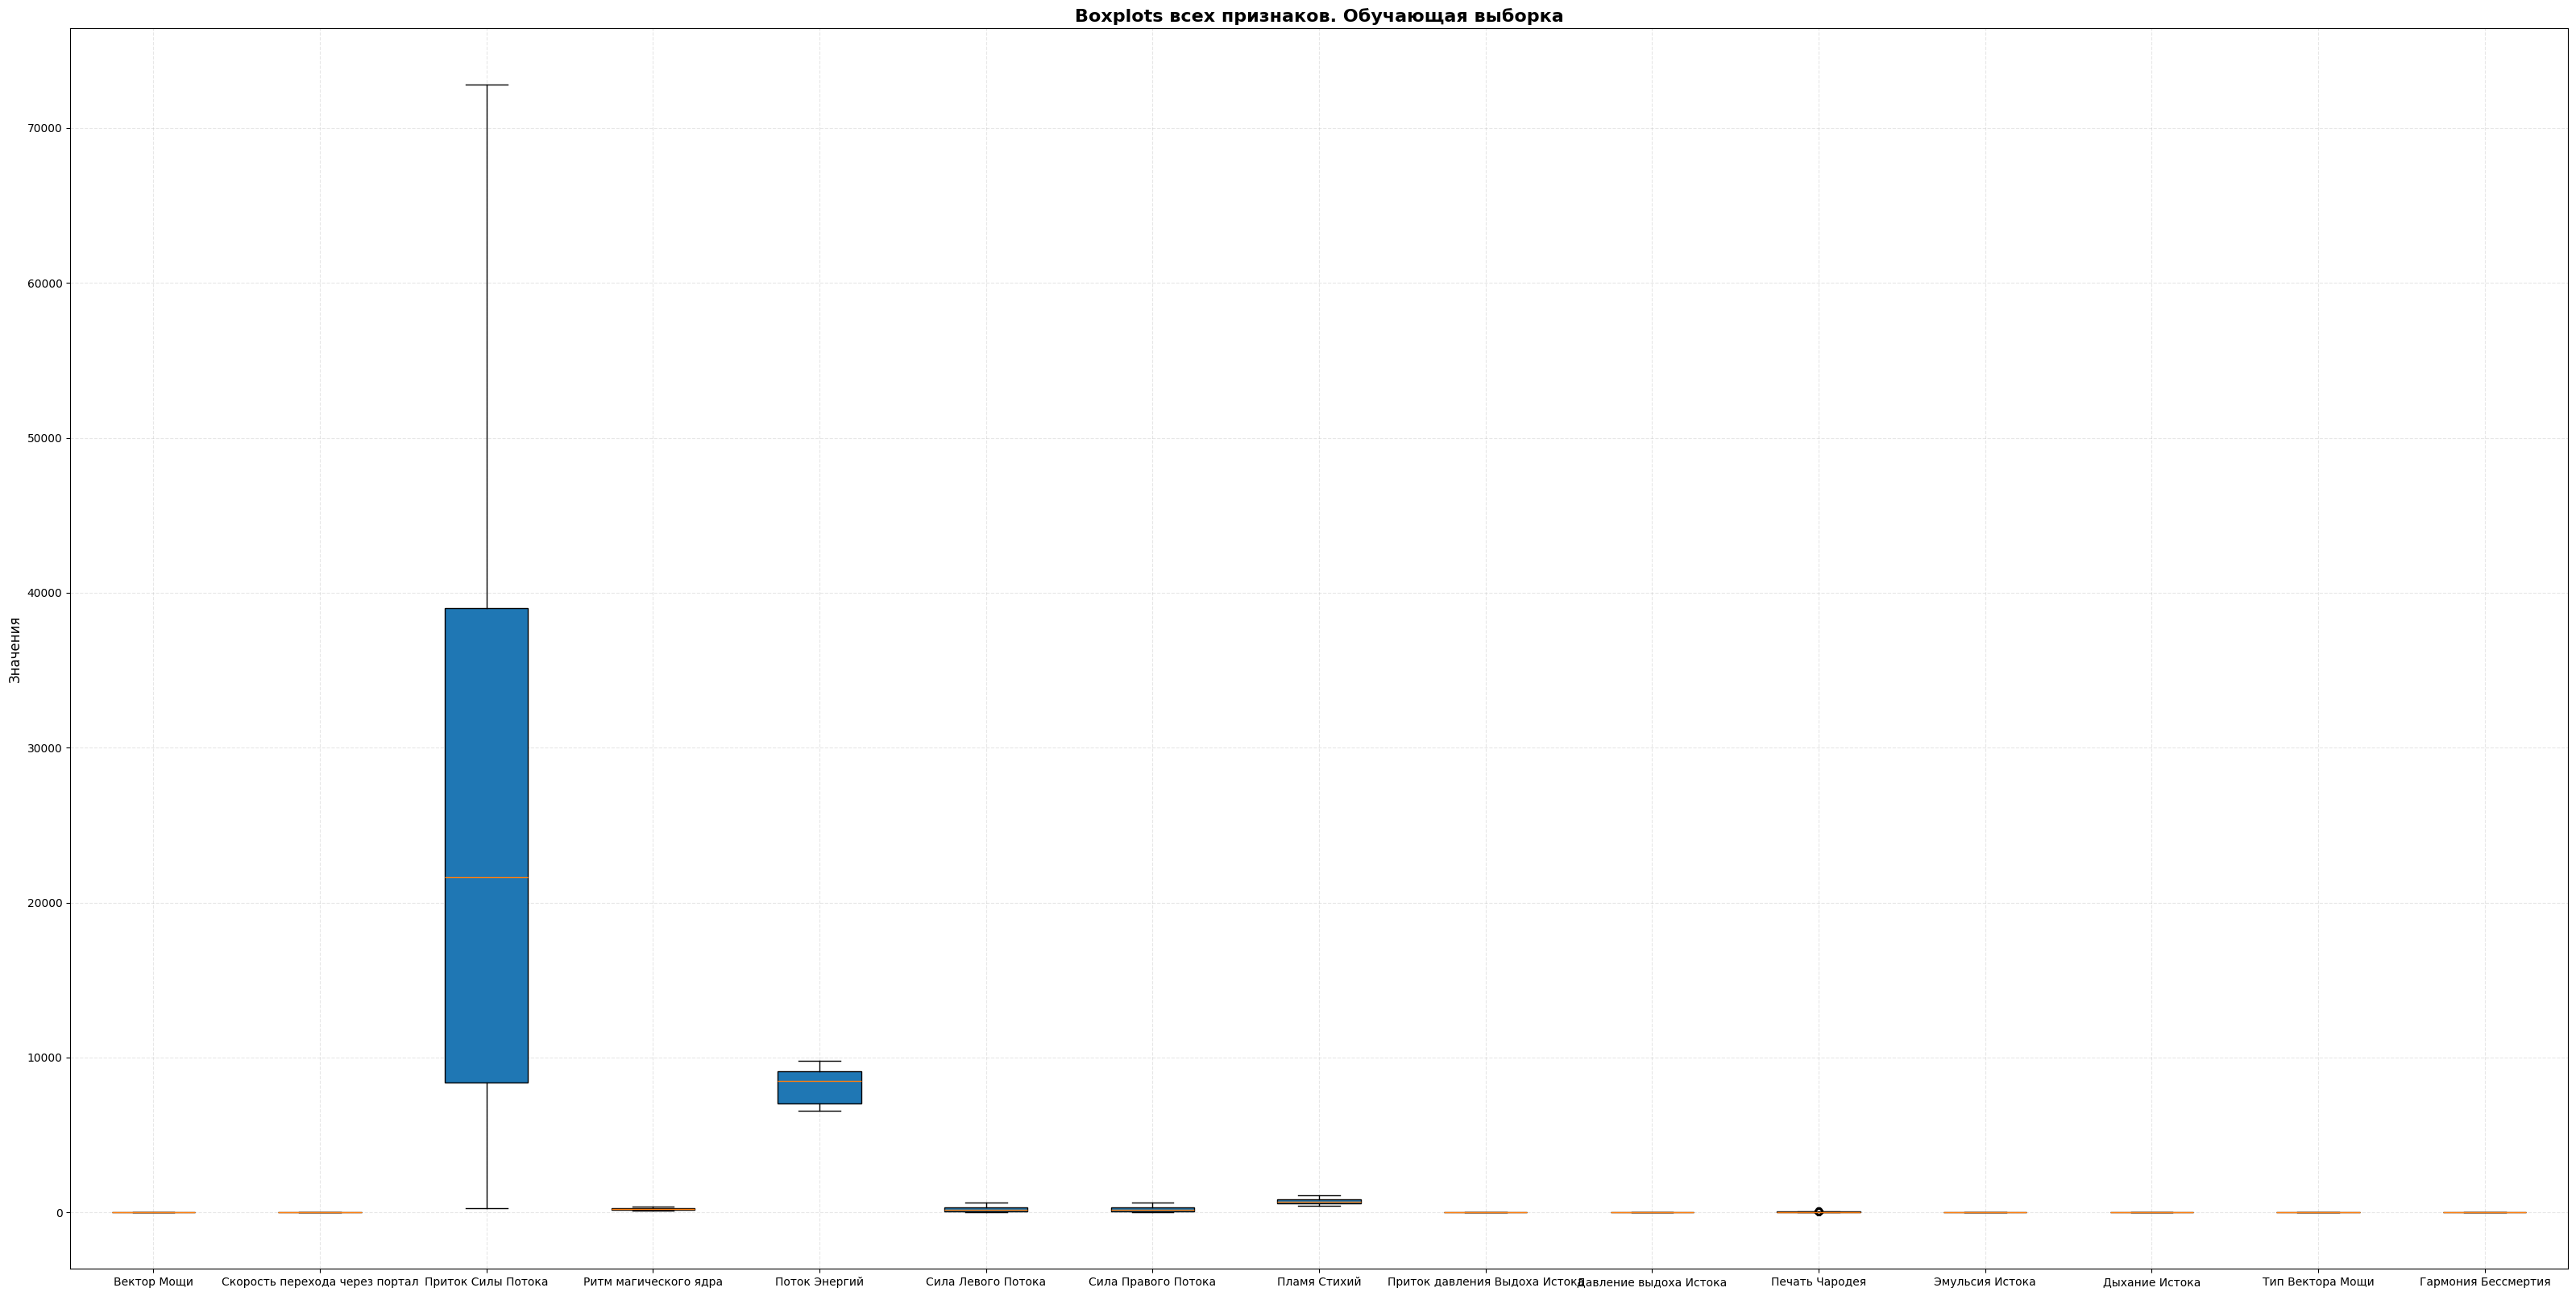

In [32]:
#Диаграмма boxplots всех выбросов (обучающей выборки)
plot_boxplots(train_sel, 'Обучающая выборка')

**Анализ диаграммы:**
- Выбросы наблюдаются в признаке `Печать Чародея`

### <font style = "color: #ba8fefff"> Обработка выбросов </font>

- Воспользуемся методом межквартильных размахов **IQR**

In [33]:
#IQR
def iqr(df : pd.DataFrame, column: str) -> pd.DataFrame:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    return df[(df[column] < lower) | (df[column] >  upper)]

In [34]:
# Определение выбрсов в выборке методом IQR

emiss_column = 'Печать Чародея'
emiss_iqr = iqr(train_sel, emiss_column)

In [35]:
emiss_iqr

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Гармония Бессмертия
15,9.3,13.88988,72774.949,372.848195,9788.415,644.979,644.979,1099.234,4.481,22.390,90.712,1.796,0.952,3.0,0.991
19,9.3,13.88988,72762.555,372.843064,9764.719,644.784,644.784,1098.829,4.511,22.841,91.319,1.808,0.963,3.0,0.977
48,9.3,13.88988,72771.424,372.846311,9778.933,645.076,645.076,1097.754,4.493,22.556,90.838,1.798,0.957,3.0,0.986
60,9.3,13.88988,72762.377,372.842855,9769.808,644.932,644.932,1105.506,4.506,22.836,91.817,1.818,0.958,3.0,0.976
203,9.3,13.88988,72767.398,372.845996,9780.868,645.036,645.036,1108.034,4.493,22.660,91.758,1.816,0.952,3.0,0.981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9399,9.3,13.88988,72769.109,372.845054,9777.762,645.092,645.092,1101.569,4.495,22.631,91.231,1.806,0.956,3.0,0.983
9423,9.3,13.88988,72766.613,372.844216,9768.017,645.088,645.088,1095.246,4.507,22.731,90.894,1.799,0.963,3.0,0.981
9458,9.3,13.88988,72769.034,372.845682,9780.085,645.074,645.074,1103.906,4.493,22.618,91.389,1.809,0.954,3.0,0.983
9465,9.3,13.88988,72775.917,372.848405,9791.421,644.946,644.946,1100.727,4.477,22.350,90.768,1.797,0.950,3.0,0.992


- Воспользуемся **Robust Z-score**

In [36]:
#Robust Z-score

from scipy import stats

def robust_zscore(df: pd.DataFrame, col: str) -> pd.Series:
    median = df[col].median()
    mad = stats.median_abs_deviation(df[col], scale='normal')
    if mad ==0:
        mad = 1e-9
    z_score = (df[col] - median)/mad

    outliers = np.abs(z_score) > 3 
    return outliers

In [37]:
# Определение выбросов методом Robust Z-score
emiss_robust = robust_zscore(train_sel, emiss_column)
emiss_robust = train_sel[emiss_robust]

In [38]:
emiss_robust

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Гармония Бессмертия
9,9.3,13.88988,72763.303,372.841912,9738.873,644.962,644.962,1063.563,4.538,22.854,88.590,1.754,0.990,3.0,0.983
15,9.3,13.88988,72774.949,372.848195,9788.415,644.979,644.979,1099.234,4.481,22.390,90.712,1.796,0.952,3.0,0.991
19,9.3,13.88988,72762.555,372.843064,9764.719,644.784,644.784,1098.829,4.511,22.841,91.319,1.808,0.963,3.0,0.977
21,9.3,13.88988,72770.614,372.845054,9758.963,644.801,644.801,1074.439,4.514,22.626,89.137,1.765,0.976,3.0,0.988
48,9.3,13.88988,72771.424,372.846311,9778.933,645.076,645.076,1097.754,4.493,22.556,90.838,1.798,0.957,3.0,0.986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9519,9.3,13.88988,72756.427,372.839818,9734.857,644.815,644.815,1073.897,4.544,23.053,89.675,1.775,0.987,3.0,0.975
9520,9.3,13.88988,72762.710,372.842226,9732.841,644.732,644.732,1054.368,4.544,22.846,87.848,1.739,0.997,3.0,0.985
9530,9.3,13.88988,72758.486,372.841179,9730.414,644.760,644.760,1060.879,4.548,22.969,88.530,1.752,0.995,3.0,0.980
9536,9.3,13.88988,72769.245,372.843588,9737.897,644.840,644.840,1045.364,4.538,22.643,86.861,1.719,0.999,3.0,0.993


### <font style = "color: #c0f0c9ff"> Пересечение выборок </font>

В результате обработки выбросов двумя методами, получены разные выборки, из которых следует сделать одну: **пересечение двух выборок**

In [39]:
#Пересечение индексов двух выборок

intersection_index = emiss_robust.index.intersection(emiss_iqr.index)
total = emiss_robust.loc[intersection_index]

### <font style = "color: #f69b81ff"> Удаление выбросов </font>


In [40]:
#Удаление выбросов в тренировочном наборе
train_without_emiss = train_sel.drop(intersection_index).reset_index(drop=True)

### Аналогично удалим выбросы из тестовой выборки

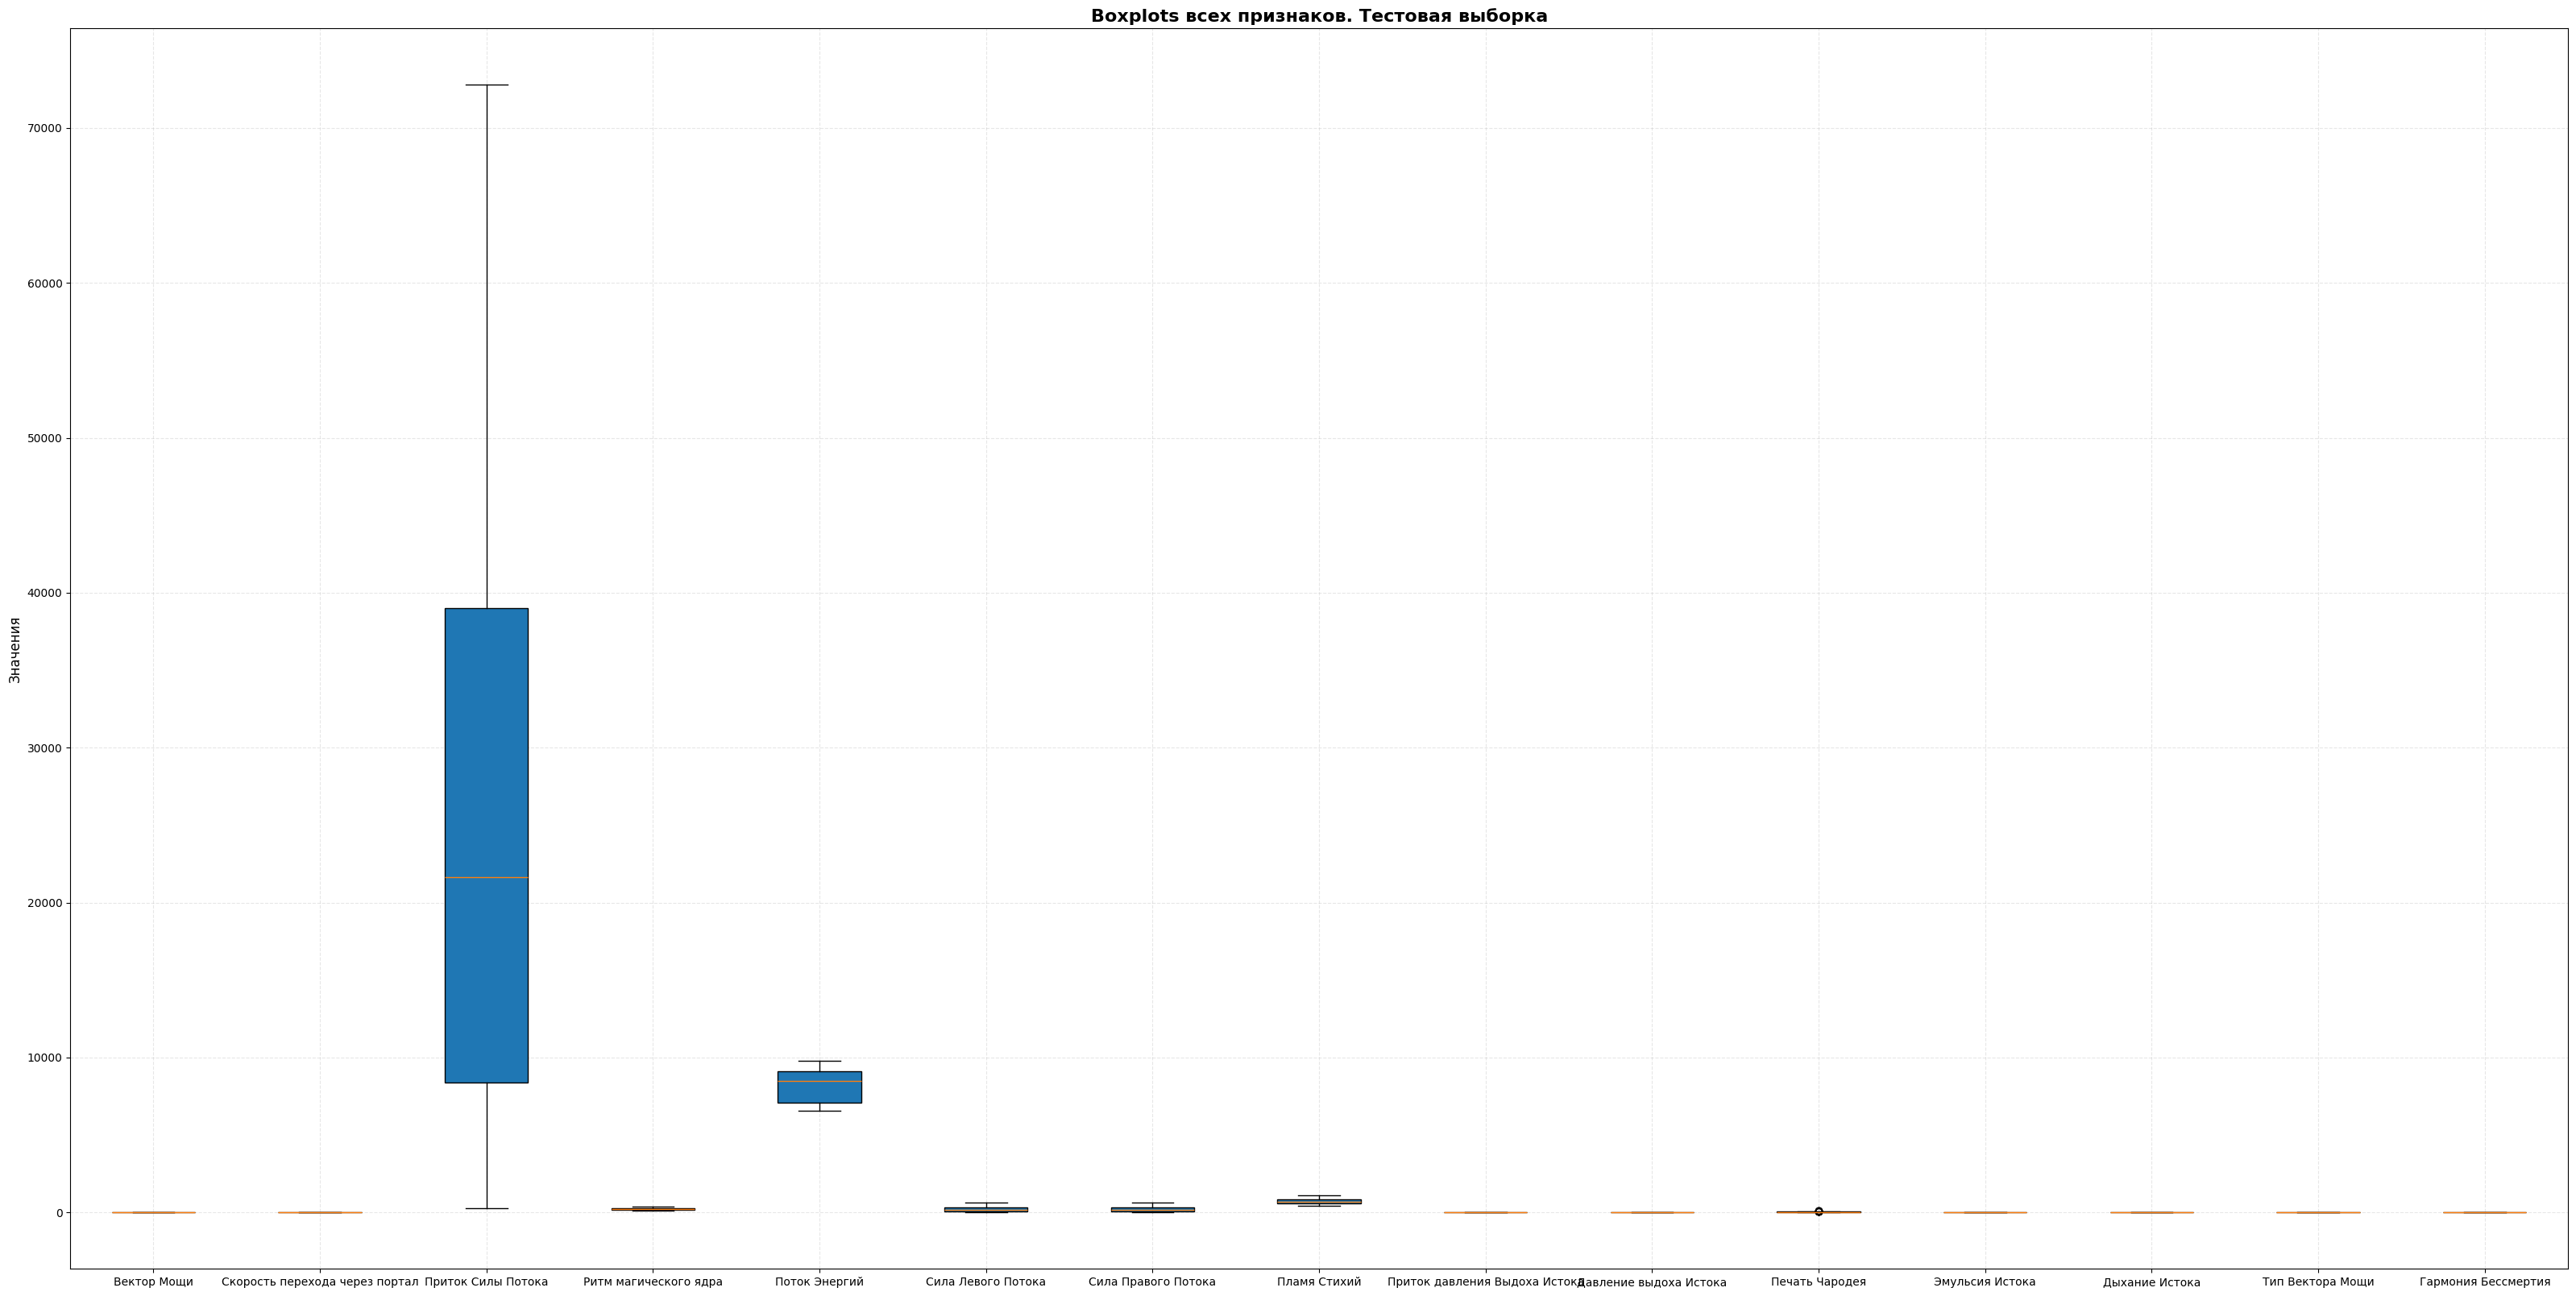

In [41]:
# Boxplpots для тестовой выборки
plot_boxplots(test_sel, 'Тестовая выборка')

- Выбросы наблюдаются в признаке `Печать Чародея`

In [42]:
emiss_iqr_test = iqr(test_sel, emiss_column) #Выбросы по IQR

emiss_robust_test = robust_zscore(test_sel, emiss_column) #Выбросы по Robust Z-score
emiss_robust_test = test_sel[emiss_robust_test]

intersection_index_test = emiss_robust_test.index.intersection(emiss_iqr_test.index) # Пересечение выбросов

test_without_emiss = test_sel.drop(intersection_index_test).reset_index(drop=True) # Удаление выбросов из тестового набора


### Визуализация выбросов

In [43]:
#Функция для визуализации выбросов
def plot_emiss(selection:pd.DataFrame, emiss:pd.DataFrame, name:str, label1: str = 'Полный датасет', label2: str = 'Выбросы'):
    data = {
        'Dataset': [label1, label2],
        'Строки': [selection.shape[0], emiss.shape[0]]
    }

    comparsion_df = pd.DataFrame(data)
    plt.title(f'Выборка {name}')
    plt.bar(comparsion_df['Dataset'], comparsion_df['Строки'], color = ['skyblue', 'lightcoral'])
    plt.show()

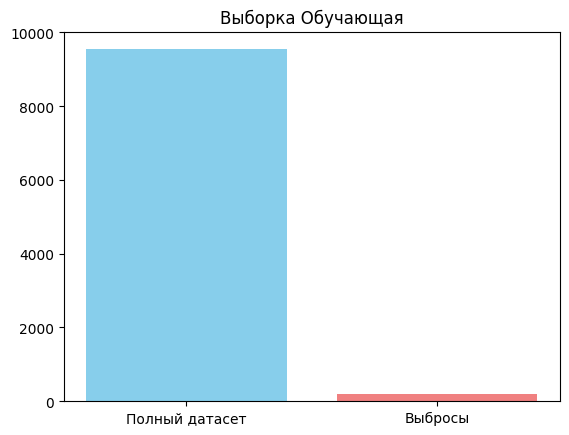

In [44]:
# Для тренировочной выборки
plot_emiss(train_sel, total, 'Обучающая')

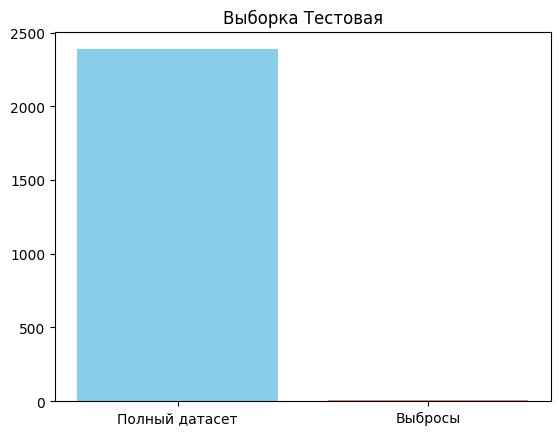

In [45]:
# Для тестовой выборки
plot_emiss(test_sel, test_sel.loc[intersection_index_test], 'Тестовая')

### <font style = "color: #b681f6ff"> Поиск аномалий </font>

Для поиска аномалий будем использовать три алгоритма:
- **Isolation Forest** - изолирует аномалии случайным разбиением пространства
- **One-Class SVM** - обучается только на нормальных данных, выявляет отклонения
- **DBSCAN** - находит плотные скопления, выбросы вне кластеров

<font style = "color: #f6aa81ff"> В итоге берём пересечение трёх выборок </font>

In [46]:
#imports
from pyod.models.iforest import IForest
from pyod.models.ocsvm import OCSVM
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [47]:
#Визуализация аномалий
def visualize(X_scaled, predictions, algorithm_name):
    # Берем первые два признака
    X_vis = X_scaled[:, [7, 14]]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Разделяем нормальные и аномальные точки
    normal_points = X_vis[predictions == 0]
    anomaly_points = X_vis[predictions == 1]
    
    # Нормальные точки (синие)
    ax.scatter(normal_points[:, 0], normal_points[:, 1], 
               c='blue', alpha=0.5, s=20, label=f'Норма ({len(normal_points)})')
    
    # Аномалии (красные)
    if len(anomaly_points) > 0:
        ax.scatter(anomaly_points[:, 0], anomaly_points[:, 1], 
                   c='red', s=60, alpha=0.8, label=f'Аномалии ({len(anomaly_points)})')
    
    # Настройки графика
    ax.set_title(f'{algorithm_name}\nНайдено аномалий: {len(anomaly_points)}')
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [48]:
#Функция для поиска и удаления аномалий

def get_select_without_anomaly(df: pd.DataFrame, name:str)-> pd.DataFrame:
    X = df.select_dtypes(include=[np.number]).values 
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Isolation Forest
    iforest = IForest(contamination=0.1)
    iforest.fit(X_scaled)
    iforest_pred = iforest.labels_

    visualize(X_scaled, iforest_pred, 'Isolation Forest' )

    # One-Class SVM
    ocsvm = OCSVM(contamination=0.1, kernel='rbf', nu=0.1)
    ocsvm.fit(X_scaled)
    ocsvm_pred = ocsvm.labels_

    visualize(X_scaled, ocsvm_pred, 'One-Class SVM' )

    # DBSCAN
    dbscan = DBSCAN(eps=0.5, min_samples=10)
    dbscan_pred = dbscan.fit_predict(X_scaled)
    dbscan_pred = np.where(dbscan_pred == -1, 1, 0)

    visualize(X_scaled, dbscan_pred, 'DBSCAN' )
    
    #Пересечение
    common_anomalies = np.logical_and.reduce([
    iforest_pred == 1,
    ocsvm_pred == 1,
    dbscan_pred == 1
    ])

    #Статистика
    print(f"Isolation Forest: {np.sum(iforest_pred == 1)} аномалий")
    print(f"One-Class SVM: {np.sum(ocsvm_pred == 1)} аномалий")
    print(f"DBSCAN: {np.sum(dbscan_pred == 1)} аномалий")
    print(f"Общие аномалии (пересечение всех трёх): {np.sum(common_anomalies)} строк")

    #Соотнесение количества аномалий с данными
    plot_emiss(df, df[common_anomalies], name, 'Полный датасет', 'Аномалии')
    
    # Удаление аномалий из датасета
    df_clean = df[~common_anomalies].copy().reset_index(drop=True)
    return df_clean



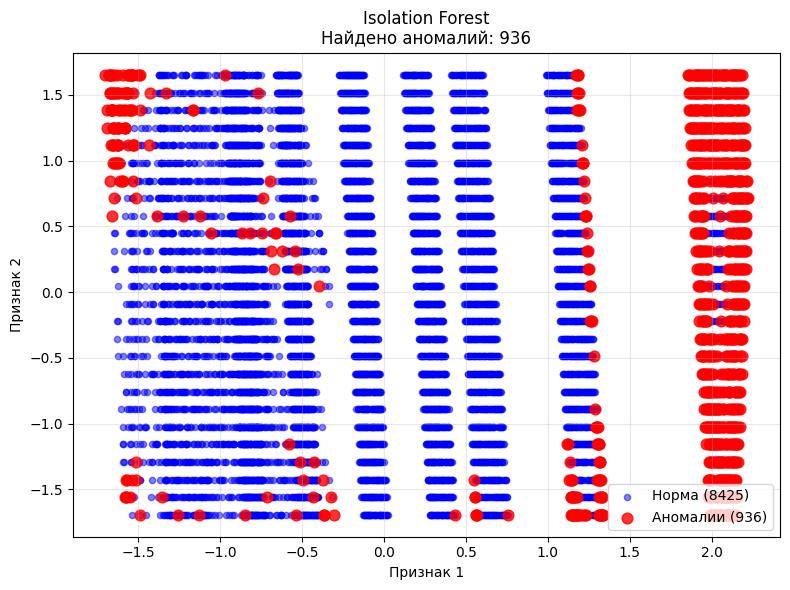

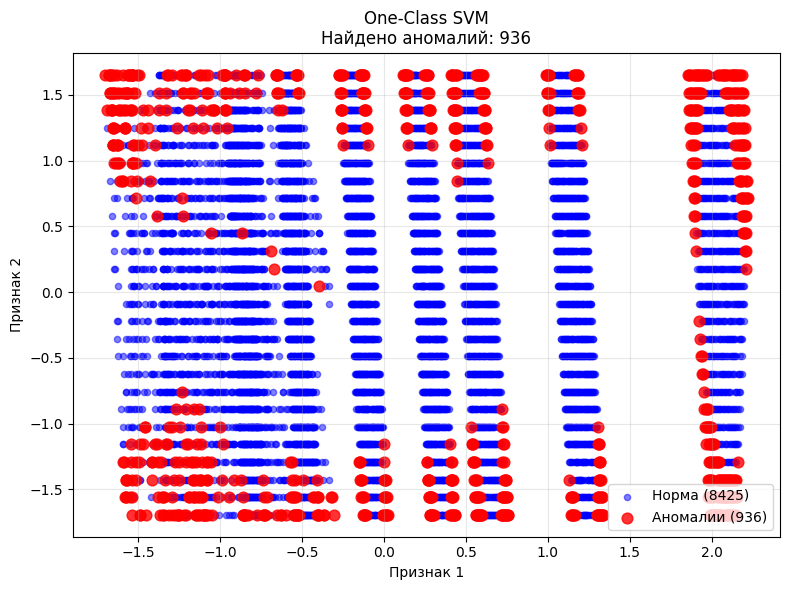

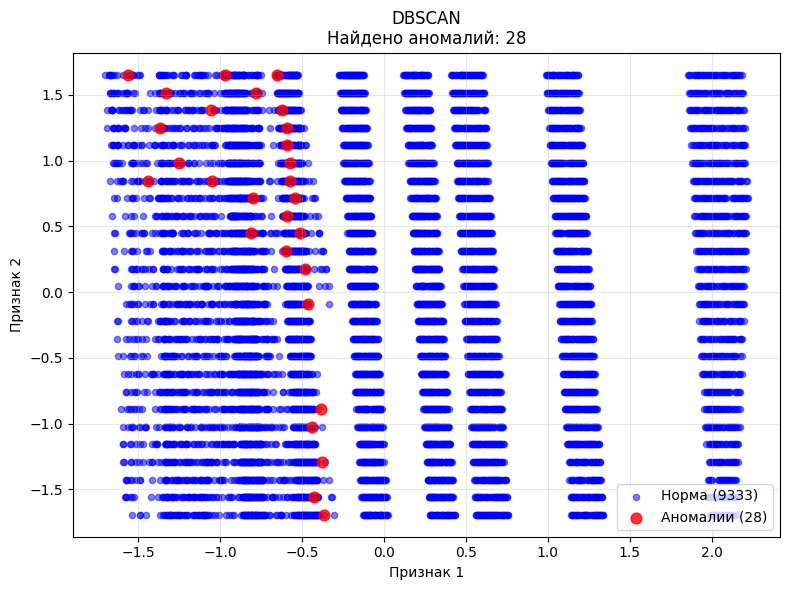

Isolation Forest: 936 аномалий
One-Class SVM: 936 аномалий
DBSCAN: 28 аномалий
Общие аномалии (пересечение всех трёх): 4 строк


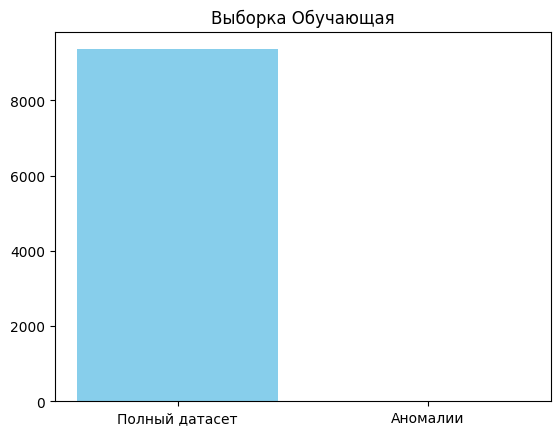

In [49]:
# Удаление аномалий в тренировочной выборке
new_train_select = get_select_without_anomaly(train_without_emiss, 'Обучающая')

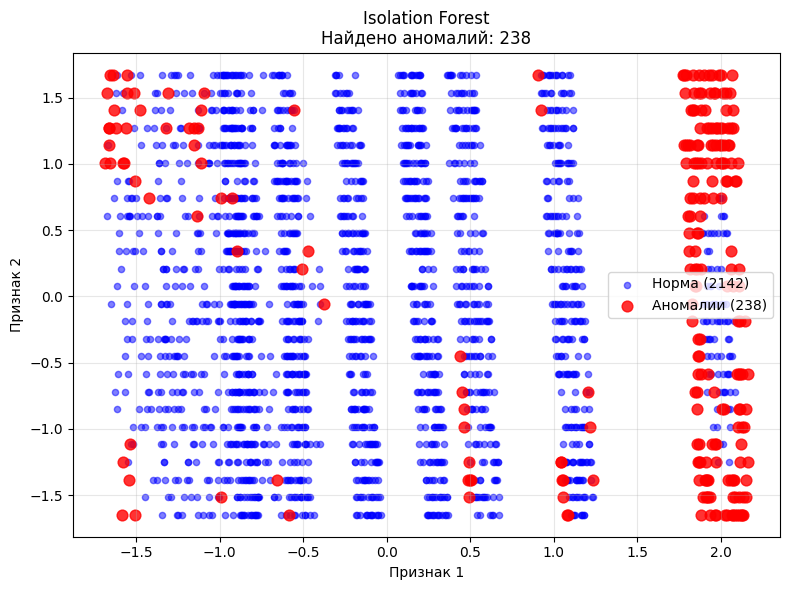

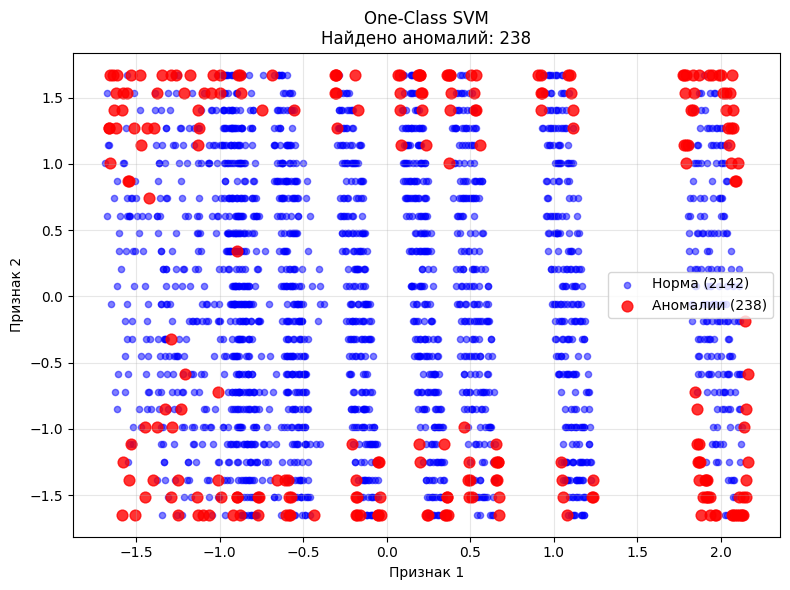

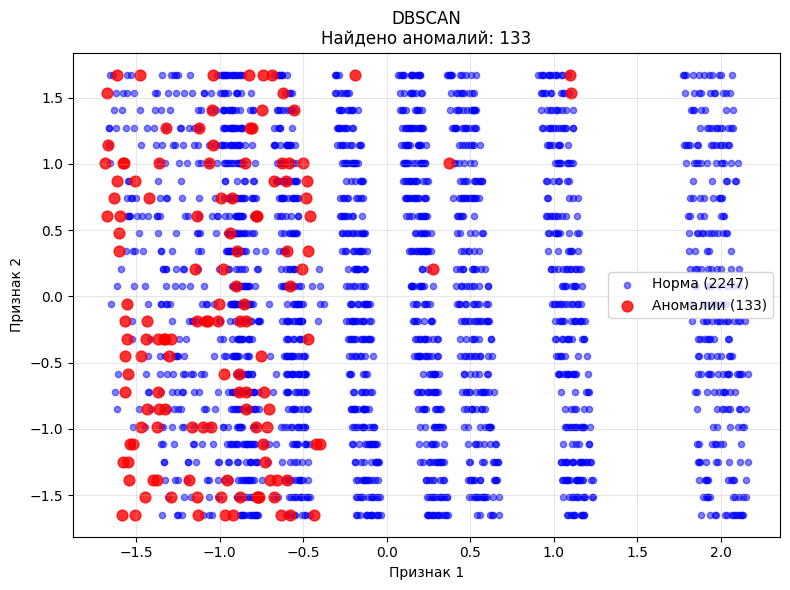

Isolation Forest: 238 аномалий
One-Class SVM: 238 аномалий
DBSCAN: 133 аномалий
Общие аномалии (пересечение всех трёх): 8 строк


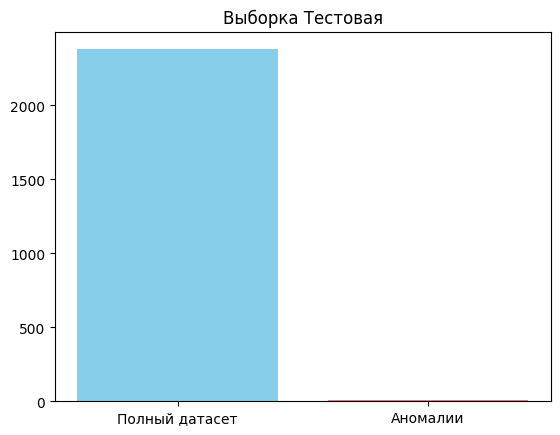

In [50]:
# Удаление аномалий в тестовой выборке

new_test_select = get_select_without_anomaly(test_without_emiss, 'Тестовая')

#### Вывод:
- Из тренировочного набора удалены 4 строк аномалий
- Из тестового набора удалены 22 строки аномалий

## 1.7. Подведение итогов раздела 1
<!-- А таких разделах обычно подытоживается вся информация о тех действиях, которые вы делали в разделе -->

В результате <font style = "color: #c766f5ff">Предварительной обработки данных </font> были:
- Проанализированы исходные данные
- Удалены лишние признаки
- Приведены типы данных
- Разбиты данные на выборки
- Восстановлены пропуски
- Удалены выбросы
- Удалены аномалии



### Сравнение строк исходной обучающей выборки до и после очистки

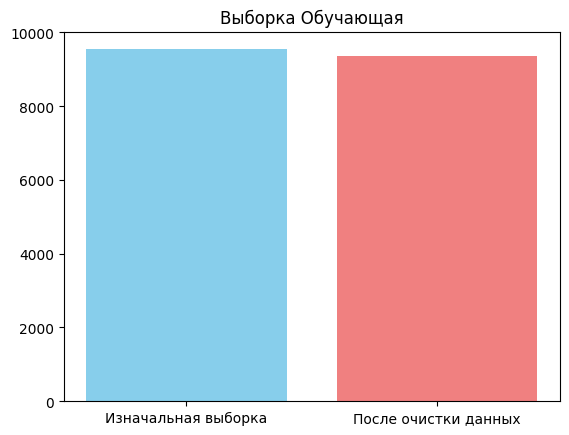

In [51]:
plot_emiss(train_selection, new_train_select, 'Обучающая', 'Изначальная выборка', 'После очистки данных')

<font style = "color: #d4ec8fff">Данные очищены и готовы к дальнейшим задачам </font>

# 2. Генерация новых признаков

## 2.1. Корреляционный анализ входных признаков (построение тепловых карт корреляции)

In [52]:
#Построение тепловой карты корреляции

def heat_map(df:pd.DataFrame):
    corr_matrix = df.corr()
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', square=True, cmap='coolwarm')
    plt.title('Тепловая карта корреляции')
    plt.tight_layout()

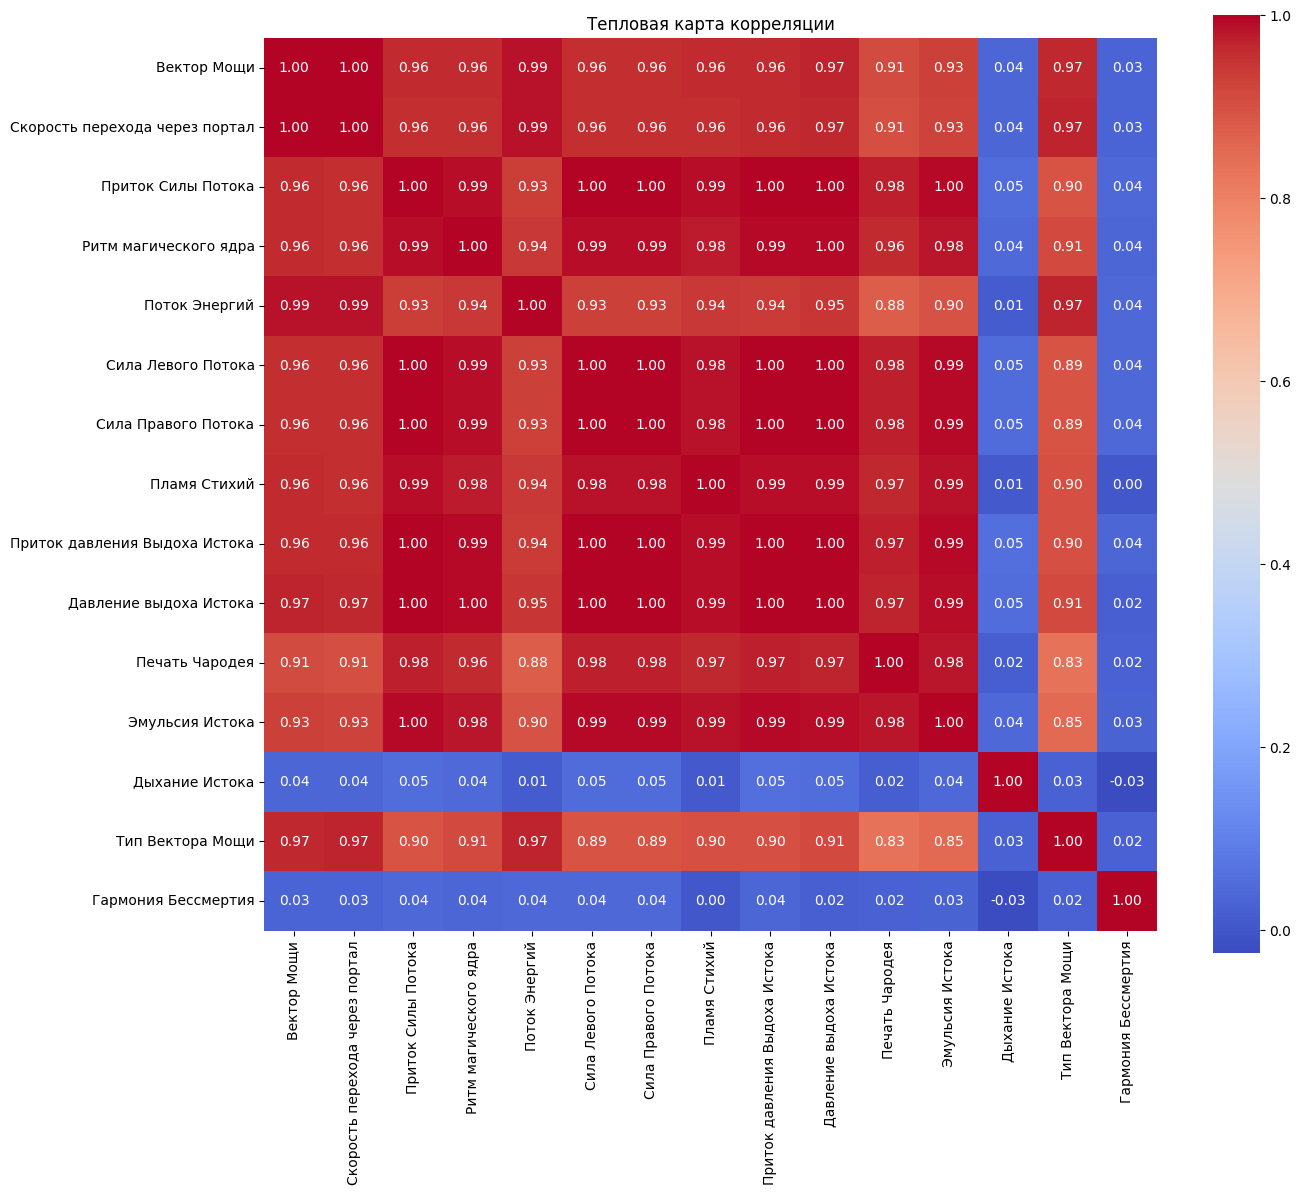

In [53]:
heat_map(new_train_select)

### Анализ корреляционной карты:
- Огромное число линейно коррелирующих признаков
- С целевым признаком `Гармония бессмертия` очень слабая корреляция, нелинейная зависимость

## 2.2. Исправление проблемы мультиколлинеарности в данных

### Добавим новые признаки в пространство


In [54]:
#Удаление старых признаков

def delete_features(selection:pd.DataFrame) -> pd.DataFrame:
    new_selection = selection.drop(['Сила Левого Потока', 'Сила Правого Потока'], axis=1)
    new_selection = selection.drop(['Приток Силы Потока','Приток давления Выдоха Истока', 'Давление выдоха Истока'], axis=1)
    return new_selection



In [55]:
# Добавление новых признаков

def add_new_features(selection:pd.DataFrame) -> pd.DataFrame:
    temp_df = selection.copy()
    selection['Совокупная мощность потоков'] = temp_df['Сила Левого Потока'] + temp_df['Сила Правого Потока']
    selection['Суммарная сила всех потоков'] = selection['Совокупная мощность потоков'] + temp_df['Приток Силы Потока']
    selection['Общая сила ядра'] = temp_df['Ритм магического ядра'] * temp_df['Приток Силы Потока']
    selection['Общее давление на выходе'] = temp_df['Приток давления Выдоха Истока'] + temp_df['Давление выдоха Истока']
    selection['Магическая производительность'] =  temp_df['Скорость перехода через портал'] / temp_df['Эмульсия Истока']
    selection['Эффективность ядра'] = selection['Общая сила ядра'] / temp_df['Эмульсия Истока']
    selection['Магическая мощность'] =  temp_df['Вектор Мощи'] * np.log2(temp_df['Пламя Стихий']) + temp_df['Эмульсия Истока'] * np.sin(temp_df['Поток Энергий'])
    return selection

In [56]:
new_train_select = add_new_features(new_train_select)
new_test_select = add_new_features(new_test_select)

new_train_select = delete_features(new_train_select)
new_test_select= delete_features(new_test_select)

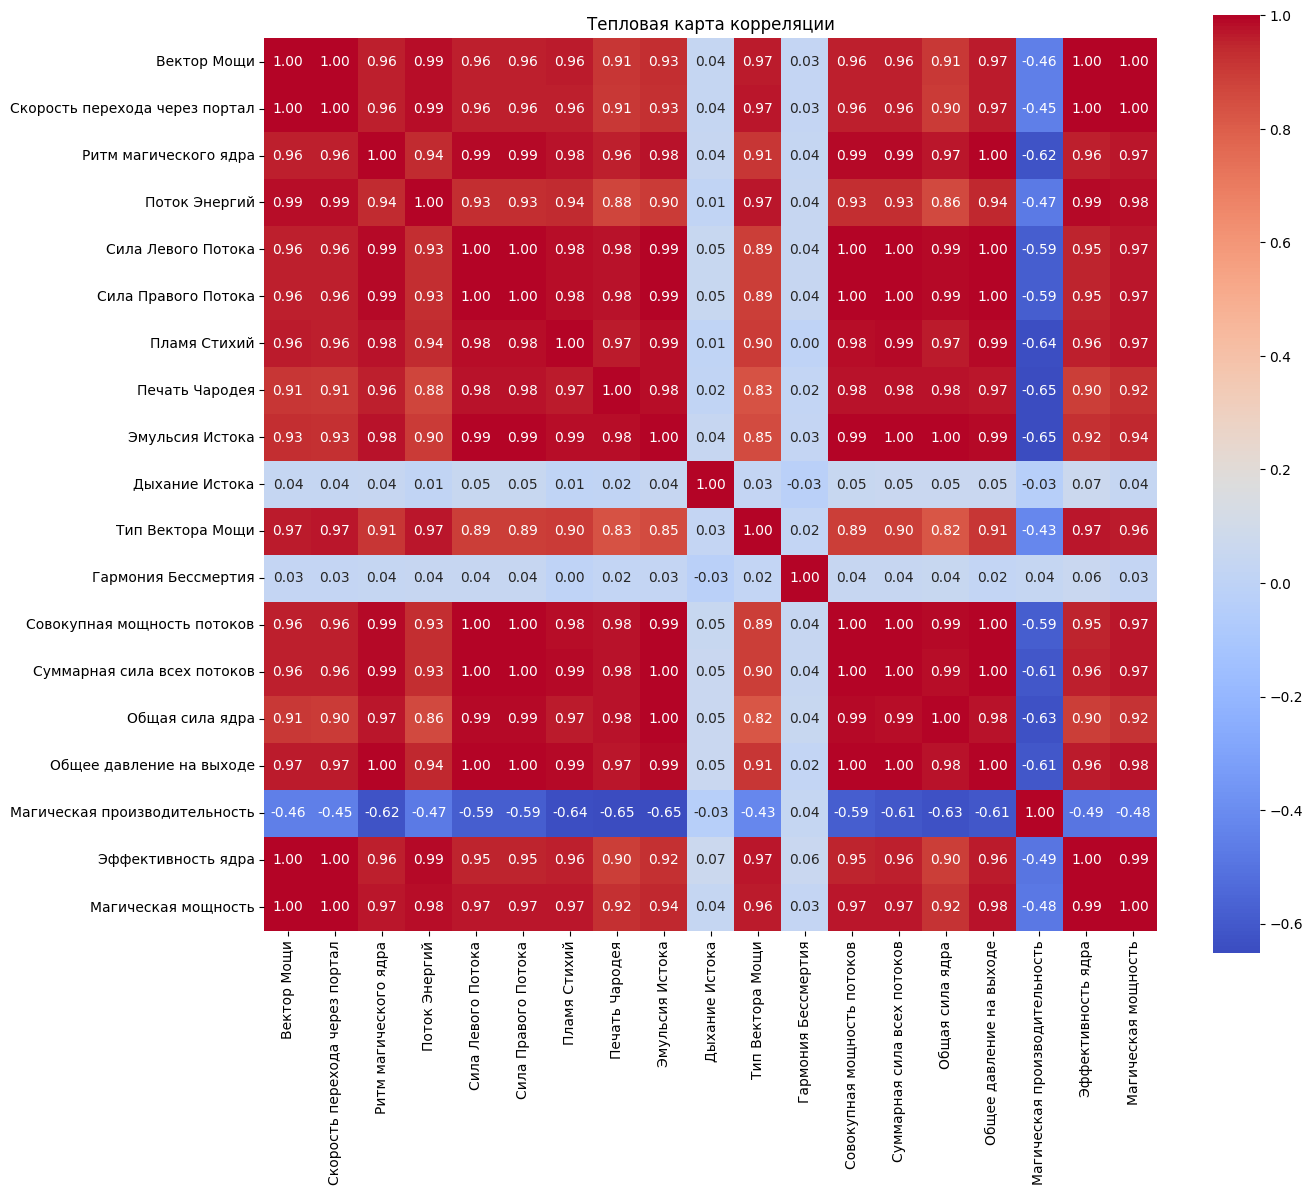

In [57]:
heat_map(new_train_select)

### Анализ добавления новых признаков
- Размерность пространства увеличилась
- Добавились новые признаки с высокой корреляцией
- Проблема мультиколлинеарности осталась

### Проблема диспропорции значений признаков

In [58]:
new_train_select.describe()

,Вектор Мощи,Скорость перехода через портал,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Гармония Бессмертия,Совокупная мощность потоков,Суммарная сила всех потоков,Общая сила ядра,Общее давление на выходе,Магическая производительность,Эффективность ядра,Магическая мощность
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9.357000e+03,9357.000000,9357.000000,9.357000e+03,9357.000000
mean,5.076531,7.581945,220.543882,8166.276082,218.617967,218.617967,727.700525,32.451938,0.638575,0.975407,1.635460,0.987655,437.235935,26730.683317,7.475537e+06,14.384600,13.958593,8.642442e+06,48.893693
std,2.588615,3.930547,79.098662,1080.020742,193.714621,193.714621,167.637747,24.783179,0.485878,0.014644,1.153352,0.007479,387.429242,21813.654409,8.128637e+06,6.237845,4.233969,4.362167e+06,26.264517
min,1.138000,1.543320,136.939406,6589.002000,5.304000,5.304000,442.364000,0.000000,0.068000,0.950000,0.000000,0.975000,10.608000,267.547000,3.556916e+04,6.924000,4.566036,4.373923e+05,9.937990
25%,3.144000,4.629960,145.220853,7049.195000,60.312000,60.312000,588.958000,13.015000,0.245000,0.963000,1.000000,0.981000,120.624000,8496.054000,1.216269e+06,8.826000,10.472061,4.886906e+06,28.705105
50%,5.140000,7.716600,201.514529,8477.055000,175.256000,175.256000,703.081000,25.123000,0.493000,0.976000,2.000000,0.988000,350.512000,21979.444000,4.358545e+06,13.139000,13.677873,8.734304e+06,48.491816
75%,7.148000,10.803240,280.447463,9129.062000,332.308000,332.308000,829.195000,44.226000,0.876000,0.988000,3.000000,0.994000,664.616000,39661.049000,1.093640e+07,18.570000,17.945581,1.262856e+07,69.541821
max,9.300000,13.889880,372.879926,9797.103000,645.249000,645.249000,1099.863000,90.689000,1.795000,1.000000,3.000000,1.000000,1290.498000,74075.284000,2.714001e+07,27.691000,25.094634,1.592358e+07,95.686739


- Большой диапозон значений: `Совокупная мощность потоков`, `Cуммарная сила всех потоков` (необходимо скалирование)
- Признак `Дыхание Истока`: std почти 0 (удалить признак)
- std `Эмульсия Истока` и std `Суммарная сила всех потоков` различаются в более чем 100 раз (диспропорция)

In [59]:
#Удаление признака `Дыхание Истока`

new_train_select = new_train_select.drop(['Дыхание Истока'], axis=1)
new_test_select = new_test_select.drop(['Дыхание Истока'], axis=1)

## 2.3. Скалирование данных

Для решения диспропорции признаков применим **Стандартное скалирование** к данным:



In [60]:
# Скалирование обучающей выборки
target_col = 'Гармония Бессмертия'
Y_train = new_train_select[target_col]
X_train_select = new_train_select.drop([target_col], axis=1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_select)

In [61]:
# Скалирование тестовой выборки

Y_test = new_test_select[target_col]
X_test_select = new_test_select.drop([target_col], axis=1)

X_test_scaled = scaler.transform(X_test_select)

In [62]:
# Скалирвоанная обучающая выборка
pd.DataFrame(X_train_scaled).describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
count,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03,9.357000e+03
mean,-1.214992e-16,-2.828654e-16,7.517765e-17,-6.610318e-16,6.815348e-17,6.815348e-17,-5.881323e-16,-5.809182e-17,6.644490e-18,3.265292e-17,6.815348e-17,7.365891e-17,4.784033e-17,-6.378710e-17,-4.472691e-16,3.204542e-16,-2.392016e-16
std,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00,1.000053e+00
min,-1.521563e+00,-1.536414e+00,-1.057021e+00,-1.460489e+00,-1.101235e+00,-1.101235e+00,-1.702193e+00,-1.309504e+00,-1.174381e+00,-1.418081e+00,-1.101235e+00,-1.213210e+00,-9.153276e-01,-1.196086e+00,-2.218500e+00,-1.881058e+00,-1.483286e+00
25%,-7.465900e-01,-7.510768e-01,-9.523177e-01,-1.034370e+00,-8.172560e-01,-8.172560e-01,-8.276772e-01,-7.843213e-01,-8.100724e-01,-5.509973e-01,-8.172560e-01,-8.359720e-01,-7.700679e-01,-8.911567e-01,-8.235106e-01,-8.609797e-01,-7.687050e-01
50%,2.451989e-02,3.426041e-02,-2.405903e-01,2.877681e-01,-2.238565e-01,-2.238565e-01,-1.468693e-01,-2.957381e-01,-2.996289e-01,3.160867e-01,-2.238565e-01,-2.178220e-01,-3.834786e-01,-1.996950e-01,-6.630547e-02,2.105999e-02,-1.530197e-02
75%,8.002657e-01,8.195976e-01,7.573678e-01,8.914990e-01,5.869258e-01,5.869258e-01,6.054716e-01,4.751082e-01,4.886770e-01,1.183171e+00,5.869258e-01,5.927964e-01,4.257850e-01,6.710047e-01,9.417171e-01,9.138422e-01,7.862026e-01
max,1.631643e+00,1.604935e+00,1.926002e+00,1.510077e+00,2.202486e+00,2.202486e+00,2.220158e+00,2.349988e+00,2.380200e+00,1.183171e+00,2.202486e+00,2.170527e+00,2.419289e+00,2.133287e+00,2.630306e+00,1.669246e+00,1.781702e+00


## 2.4. Подведение итогов раздела 2
<!-- А таких разделах обычно подытоживается вся информация о тех действиях, которые вы делали в разделе -->

В результате раздела 2 были выполнены следующие задачи:
1. Проведён корреляционный анализ данных
    - Выявлена мультиколлинеарность 
    - Нелинейная зависимость признаков с целевой переменной
2. Добавлены новые признаки из предметной области
    - Расчитываются по исходным признакам
    - Большинство также имеют линейную зависимость с признаками
3. Проблема мультиколлинеарности не была устранена
    - Возможное решение - использование PCA
4. Проанализирована дипропорция признаков
    - Большие диапозоны значений
    - Большая разница между стандартными отклонениями
5. Скалирование данных

# 3. Выбор моделей ML и метрик


<!-- Третий раздел самый богатый на писанину. Вам необходимо сначала обосновать выбор моделей, а затем все отобранные модели описать (расписать концептуально, как они работают) -->


<font size = 5>Выбор моделей машинного обучения для задачи регрессии</font>

<font size = 4>Контекст задачи </font>

| Параметр | Характеристика | Влияние на выбор модели |
|----------|----------------|-------------------------|
| **Тип задачи** | Регрессия (непрерывная целевая переменная) | Требуются регрессионные модели |
| **Целевая переменная** | `Гармония Бессмертия` - показатель стабильности портала | Важна точность прогноза |
| **Зависимости** | Нелинейные (корреляция с целевой ≈ 0) | Нужны модели, улавливающие нелинейность |
| **Мультиколлинеарность** | Высокая между признаками | Модели должны быть устойчивы к корреляции признаков |
| **Особенности** | Физические/магические параметры, возможны шумы | Робастность к выбросам важна |

<font size = 5> Рекомендуемые модели</font>

<font size  = 4>1. **Random Forest Regressor** </font> 

<font size = 3> Обоснование</font>

1. Устойчив к мультиколлинеарности - деревья выбирают информативные признаки
2. Улавливает нелинейные зависимости - не делает предположений о линейности
3. Робастен к выбросам - использует медианное усреднение
4. Не требует масштабирования данных - инвариантен к масштабу
5. Предоставляет важность признаков - помогает в интерпретации
6. Меньше переобучается по сравнению с одним деревом

<font size = 3> Концепт работы</font>

1. Создание множества решающих деревьев:
   - Каждое дерево обучается на случайной подвыборке данных (bootstrap)
   - В каждом узле выбирается случайное подмножество признаков

2. Процесс предсказания:
   - Каждое дерево дает свой прогноз
   - Итоговый прогноз = среднее значение всех предсказаний

3. Особенности:
   - Bagging (Bootstrap Aggregating) подход
   - Снижение дисперсии за счет усреднения
   - Естественная регуляризация через ограничение глубины

<font size  = 4>2. **Gradient Boosting Regressor** </font> 

<font size = 3> Обоснование</font>

1. Высокая точность на сложных нелинейных задачах
2. Эффективно обрабатывает взаимодействия признаков
3. Встроенные механизмы борьбы с переобучением (регуляризация)
4. Быстрая скорость обучения (особенно LightGBM)
5. Автоматический отбор признаков
6. Хорошо работает с данными, где мало линейных зависимостей

<font size = 3> Концепт работы</font>

1. Последовательное построение ансамбля:
   - Первая модель обучается на исходных данных
   - Каждая следующая модель обучается на ошибках предыдущих
   - Градиентный спуск в пространстве функций

2. Алгоритмические особенности:
   - Минимизация градиента функции потерь
   - Постепенное улучшение предсказаний
   - Комбинация слабых учеников (неглубоких деревьев)

3. Регуляризация:
   - Ограничение максимальной глубины деревьев
   - Минимальное количество образцов в листьях

<font size  = 4>3. **Support Vector Regression (SVR)**</font> 

<font size = 3> Обоснование</font>

1. Эффективен в высокоразмерных пространствах
2. Улавливает сложные нелинейные зависимости через kernel trick
3. Устойчив к переобучению (максимизация margin)
4. Робастен к выбросам (использует epsilon-трубку)

<font size = 3> Концепт работы</font>

1. Принцип максимального зазора:
   - Ищет функцию, которая отклоняется от фактических значений
     не более чем на ε (эпсилон-трубка)
   - Максимизирует "зазор" для лучшей обобщающей способности

2. Kernel trick для нелинейности:
   - RBF (Radial Basis Function) ядро: $K(\mathbf{x}, \mathbf{x}') = \exp\left(-\gamma \|\mathbf{x} - \mathbf{x}'\|^2\right)$
   - Линейная регрессия в новом пространстве

3. Параметры настройки:
   - C: штраф за ошибки (регуляризация)
   - ε: ширина трубки допуска
   - γ: параметр радиуса влияния RBF ядра


<font size  = 5>Выбор метрик</font> 

| Метрика | Обоснование выбора | Особенности для нашей задачи |
|---------|-------------------|------------------------------|
| **MSE** | Основная метрика для регрессии, чувствительна к большим ошибкам | Показывает среднее качество модели по всем предсказаниям |
| **MAE** | Более робастная метрика, менее чувствительна к выбросам | Лучше отражает типичную ошибку в исходных единицах |
| **R²** | Показывает долю объясненной дисперсии, нормализованная метрика | Позволяет сравнивать модели независимо от масштаба данных |
| **RMSE** | Имеет ту же размерность, что и целевая переменная | Интерпретируемость в исходных единицах измерения |

<font size  = 4>1. **Mean Squared Error (MSE)**</font> 

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

**Где:**
- $n$ - количество наблюдений
- $y_i$ - истинное значение целевой переменной
- $\hat{y}_i$ - предсказанное значение
- $(y_i - \hat{y}_i)$ - ошибка предсказания для i-го наблюдения

<font size  = 4>2. **Root Mean Squared Error (RMSE)**</font> 

$$
\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} = \sqrt{\text{MSE}}
$$


**Интерпретация:** RMSE показывает среднее отклонение предсказаний от истинных значений в тех же единицах измерения, что и целевая переменная.

<font size  = 4>3. **Mean Absolute Error (MAE)**</font> 

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

**Особенности:** Менее чувствительна к выбросам, чем MSE, так как использует абсолютные значения вместо квадратов.

**Где:**
- $n$ - количество наблюдений
- $y_i$ - истинное значение целевой переменной
- $\hat{y}_i$ - предсказанное значение
- $(y_i - \hat{y}_i)$ - ошибка предсказания для i-го наблюдения

<font size  = 4>4. **R² (Коэффициент детерминации)**</font> 

$$
R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}} = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$

**Где:**
- $\text{SS}_{\text{res}}$ - сумма квадратов остатков
- $\text{SS}_{\text{tot}}$ - общая сумма квадратов
- $\bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i$ - среднее значение целевой переменной

**Интерпретация:**
- $R^2 = 1$: идеальное предсказание
- $R^2 = 0$: модель не лучше, чем предсказание средним значением
- $R^2 < 0$: модель хуже, чем предсказание средним значением


<font size  = 5>Выбор метрики для обучения</font> 

Нас интересует:
1. Чувстительность к большим ошибкам
2. Дифференцируемость для градиентных методов
3. Интерпретируемость в исходных единицах целевой переменной

Идеальная метрика: **Root Mean Squared Error (RMSE)**

In [63]:
# Импорт моделей
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [64]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'], 
    'bootstrap': [True, False]
}

gb_params = {
    'n_estimators': [100, 200, 300],           
    'learning_rate': [0.01, 0.05, 0.1, 0.2],   
    'max_depth': [3, 5, 7, 9],                 
    'min_samples_split': [2, 5, 10],           
    'min_samples_leaf': [1, 2, 4],            
    'subsample': [0.8, 0.9, 1.0]              
}

svr_params = {
    'C': [0.1, 1, 10, 100],                    
    'epsilon': [0.01, 0.1, 0.2],               
    'kernel':  ['rbf'],      
    'gamma': ['scale', 'auto'],               
    'degree': [2, 3, 4]                       
}

# 4. Обучение моделей ML и подбор гиперпараметров

In [71]:
import optuna
from Lab1.ml_library.hyperparams import gen_objective

rf_objective = gen_objective(RandomForestRegressor, rf_params,  X_train_scaled, Y_train, metric='neg_root_mean_squared_error')

study = optuna.create_study(direction='maximize')
study.optimize(rf_objective, n_trials=20)
best_params = study.best_params

[I 2025-12-24 13:24:20,298] A new study created in memory with name: no-name-997e890e-bb53-4a3f-96f7-4d830ff0d45a


{'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': False}


[I 2025-12-24 13:24:37,184] Trial 0 finished with value: -0.0013123792021113936 and parameters: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: -0.0013123792021113936.


{'n_estimators': 100, 'max_depth': 30, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True}


[I 2025-12-24 13:24:42,355] Trial 1 finished with value: -0.0012984488166493673 and parameters: {'n_estimators': 100, 'max_depth': 30, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: -0.0012984488166493673.


...

[I 2025-12-24 13:28:23,483] Trial 17 finished with value: -0.0009090359541587504 and parameters: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False}. Best is trial 17 with value: -0.0009090359541587504.


{'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}


[I 2025-12-24 13:28:29,464] Trial 18 finished with value: -0.0010731884162615557 and parameters: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 17 with value: -0.0009090359541587504.


{'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False}


[I 2025-12-24 13:28:39,086] Trial 19 finished with value: -0.0009159758019030878 and parameters: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'bootstrap': False}. Best is trial 17 with value: -0.0009090359541587504.


In [73]:
from joblib import dump, load
rf_model = RandomForestRegressor(**best_params).fit(X_train_scaled, Y_train)

In [75]:
gb_objective = gen_objective(GradientBoostingRegressor, gb_params,  X_train_scaled, Y_train, metric='neg_root_mean_squared_error')

study_gb = optuna.create_study(direction='maximize')
study_gb.optimize(gb_objective, n_trials=15)
best_params_gb = study_gb.best_params

[I 2025-12-24 13:52:59,504] A new study created in memory with name: no-name-9bf9a023-1ebc-48df-860e-c21812ddc636


{'n_estimators': 200, 'learning_rate': 0.2, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 1, 'subsample': 1.0}


[I 2025-12-24 13:53:16,474] Trial 0 finished with value: -0.0013413368967990808 and parameters: {'n_estimators': 200, 'learning_rate': 0.2, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 1, 'subsample': 1.0}. Best is trial 0 with value: -0.0013413368967990808.


{'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 4, 'subsample': 0.8}


[I 2025-12-24 13:53:38,434] Trial 1 finished with value: -0.0015614434449954518 and parameters: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 4, 'subsample': 0.8}. Best is trial 0 with value: -0.0013413368967990808.


...

[I 2025-12-24 14:00:42,689] Trial 12 finished with value: -0.0008033276900167807 and parameters: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 9, 'min_samples_split': 10, 'min_samples_leaf': 1, 'subsample': 0.9}. Best is trial 7 with value: -0.0007740459652464246.


{'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 9, 'min_samples_split': 10, 'min_samples_leaf': 2, 'subsample': 0.9}


[I 2025-12-24 14:01:25,264] Trial 13 finished with value: -0.00264835019226899 and parameters: {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 9, 'min_samples_split': 10, 'min_samples_leaf': 2, 'subsample': 0.9}. Best is trial 7 with value: -0.0007740459652464246.


{'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 2, 'subsample': 0.8}


[I 2025-12-24 14:02:24,478] Trial 14 finished with value: -0.0007838337081567719 and parameters: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 2, 'subsample': 0.8}. Best is trial 7 with value: -0.0007740459652464246.


In [72]:
gb_model = GradientBoostingRegressor(**best_params_gb).fit(X_train_scaled, Y_train)
dump(gb_model, 'GradientBoostingRegressor.joblib')

NameError: name 'best_params_gb' is not defined

In [66]:
svm_objective = gen_objective(SVR, svr_params,  X_train_scaled, Y_train, metric='neg_root_mean_squared_error')

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(svm_objective, n_trials=100)
best_params_svm = study_svm.best_params

[I 2025-12-24 13:21:33,057] A new study created in memory with name: no-name-7bd3bf24-432c-4662-a89c-b7687726ad29
[I 2025-12-24 13:21:33,070] Trial 0 finished with value: -0.0074796120783977476 and parameters: {'C': 100, 'epsilon': 0.1, 'kernel': 'rbf', 'gamma': 'auto', 'degree': 2}. Best is trial 0 with value: -0.0074796120783977476.
[I 2025-12-24 13:21:33,082] Trial 1 finished with value: -0.0074796120783977476 and parameters: {'C': 10, 'epsilon': 0.2, 'kernel': 'rbf', 'gamma': 'auto', 'degree': 4}. Best is trial 0 with value: -0.0074796120783977476.
[I 2025-12-24 13:21:33,219] Trial 2 finished with value: -0.0057521881881136714 and parameters: {'C': 1, 'epsilon': 0.01, 'kernel': 'rbf', 'gamma': 'auto', 'degree': 4}. Best is trial 2 with value: -0.0057521881881136714.
[I 2025-12-24 13:21:33,225] Trial 3 finished with value: -0.0074796120783977476 and parameters: {'C': 100, 'epsilon': 0.2, 'kernel': 'rbf', 'gamma': 'auto', 'degree': 2}. Best is trial 2 with value: -0.00575218818811367

{'C': 100, 'epsilon': 0.1, 'kernel': 'rbf', 'gamma': 'auto', 'degree': 2}
{'C': 10, 'epsilon': 0.2, 'kernel': 'rbf', 'gamma': 'auto', 'degree': 4}
{'C': 1, 'epsilon': 0.01, 'kernel': 'rbf', 'gamma': 'auto', 'degree': 4}
{'C': 100, 'epsilon': 0.2, 'kernel': 'rbf', 'gamma': 'auto', 'degree': 2}
{'C': 100, 'epsilon': 0.2, 'kernel': 'rbf', 'gamma': 'auto', 'degree': 3}
{'C': 100, 'epsilon': 0.01, 'kernel': 'rbf', 'gamma': 'scale', 'degree': 3}


[I 2025-12-24 13:21:33,357] Trial 5 finished with value: -0.005751341881066959 and parameters: {'C': 100, 'epsilon': 0.01, 'kernel': 'rbf', 'gamma': 'scale', 'degree': 3}. Best is trial 5 with value: -0.005751341881066959.
[I 2025-12-24 13:21:33,488] Trial 6 finished with value: -0.005735571742922818 and parameters: {'C': 1, 'epsilon': 0.01, 'kernel': 'rbf', 'gamma': 'scale', 'degree': 2}. Best is trial 6 with value: -0.005735571742922818.
[I 2025-12-24 13:21:33,494] Trial 7 finished with value: -0.0074796120783977476 and parameters: {'C': 1, 'epsilon': 0.2, 'kernel': 'rbf', 'gamma': 'auto', 'degree': 3}. Best is trial 6 with value: -0.005735571742922818.
[I 2025-12-24 13:21:33,499] Trial 8 finished with value: -0.0074796120783977476 and parameters: {'C': 1, 'epsilon': 0.1, 'kernel': 'rbf', 'gamma': 'scale', 'degree': 2}. Best is trial 6 with value: -0.005735571742922818.
[I 2025-12-24 13:21:33,506] Trial 9 finished with value: -0.0074796120783977476 and parameters: {'C': 10, 'epsilon'

{'C': 1, 'epsilon': 0.01, 'kernel': 'rbf', 'gamma': 'scale', 'degree': 2}
{'C': 1, 'epsilon': 0.2, 'kernel': 'rbf', 'gamma': 'auto', 'degree': 3}
{'C': 1, 'epsilon': 0.1, 'kernel': 'rbf', 'gamma': 'scale', 'degree': 2}
{'C': 10, 'epsilon': 0.1, 'kernel': 'rbf', 'gamma': 'auto', 'degree': 3}
{'C': 0.1, 'epsilon': 0.01, 'kernel': 'rbf', 'gamma': 'scale', 'degree': 2}


[I 2025-12-24 13:21:33,729] Trial 10 finished with value: -0.005897046647209452 and parameters: {'C': 0.1, 'epsilon': 0.01, 'kernel': 'rbf', 'gamma': 'scale', 'degree': 2}. Best is trial 6 with value: -0.005735571742922818.


...

{'C': 1, 'epsilon': 0.01, 'kernel': 'rbf', 'gamma': 'scale', 'degree': 4}
{'C': 1, 'epsilon': 0.1, 'kernel': 'rbf', 'gamma': 'scale', 'degree': 3}
{'C': 100, 'epsilon': 0.01, 'kernel': 'rbf', 'gamma': 'scale', 'degree': 2}


[I 2025-12-24 13:21:43,866] Trial 96 finished with value: -0.005751341881066959 and parameters: {'C': 100, 'epsilon': 0.01, 'kernel': 'rbf', 'gamma': 'scale', 'degree': 2}. Best is trial 6 with value: -0.005735571742922818.
[I 2025-12-24 13:21:43,998] Trial 97 finished with value: -0.005735571742922818 and parameters: {'C': 1, 'epsilon': 0.01, 'kernel': 'rbf', 'gamma': 'scale', 'degree': 4}. Best is trial 6 with value: -0.005735571742922818.


{'C': 1, 'epsilon': 0.01, 'kernel': 'rbf', 'gamma': 'scale', 'degree': 4}
{'C': 0.1, 'epsilon': 0.01, 'kernel': 'rbf', 'gamma': 'scale', 'degree': 3}


[I 2025-12-24 13:21:44,222] Trial 98 finished with value: -0.005897046647209452 and parameters: {'C': 0.1, 'epsilon': 0.01, 'kernel': 'rbf', 'gamma': 'scale', 'degree': 3}. Best is trial 6 with value: -0.005735571742922818.
[I 2025-12-24 13:21:44,231] Trial 99 finished with value: -0.0074796120783977476 and parameters: {'C': 1, 'epsilon': 0.2, 'kernel': 'rbf', 'gamma': 'auto', 'degree': 2}. Best is trial 6 with value: -0.005735571742922818.


{'C': 1, 'epsilon': 0.2, 'kernel': 'rbf', 'gamma': 'auto', 'degree': 2}


In [68]:
svm_model = SVR(**best_params_svm).fit(X_train_scaled, Y_train)
# dump(svm_model, 'SVM_RBF.joblib')

# 5. Вычисление метрик на новых данных

In [69]:
from Lab1.ml_library.metrics_regression import print_error
from Lab1.ml_library.graphics import plot_distplot_regressors

In [74]:
print_error(Y_test, rf_model.predict(X_test_scaled))

      Метрики качества
MAE            0.00038
MSE            0.00000
RMSE           0.00000
MAPE           0.00039
R^2            0.99031


In [ ]:
PATH = '/Users/danilaskiba/git_repository/Machine-Learning/Practicum/Lab4/models/'

regressors  = {
    'RandomForestRegressor': load(f'{PATH}RandomForestRegressor.joblib'),
    'GradientBoostingRegressor': load(f'{PATH}GradientBoostingRegressor.joblib'), 
    'SVR': load(f'{PATH}SVM_RBF.joblib')
}

In [ ]:
#Метрики RandomForest
print_error(Y_test,regressors['RandomForestRegressor'].predict(X_test_scaled))

      Метрики качества
MAE            0.00240
MSE            0.00001
RMSE           0.00316
MAPE           0.00243
R^2            0.76133


In [ ]:
#Метрики GradientBoosting
print_error(Y_test, regressors['GradientBoostingRegressor'].predict(X_test_scaled))

      Метрики качества
MAE            0.00544
MSE            0.00004
RMSE           0.00632
MAPE           0.00551
R^2            0.27403


In [ ]:
#Метрики SVR_RBF
print_error(Y_test, regressors['SVR'].predict(X_test_scaled))

      Метрики качества
MAE            0.00652
MSE            0.00006
RMSE           0.00775
MAPE           0.00660
R^2           -0.00007


<font size = 5> График распределения предсказаний и реальных данных</font>

In [ ]:

plot_distplot_regressors(regressors, X_test_scaled, Y_test, x_title=' ', y_title=' ', nameplot='График плотности распределений предсказаний')

<font size = 5> Сводная таблица метрик</font>

| Модель              | MAE     | MSE       | RMSE    | MAPE    | R²      |
|---------------------|---------|-----------|---------|---------|---------|
| **RandomForest**    | **0.00240** | **0.00001** | **0.00316** | **0.00243** | **0.76133** |
| GradientBoosting    | 0.00544 | 0.00004    | 0.00632 | 0.00551 | 0.27403 |
| SVM                 | 0.00652 | 0.00006    | 0.00775 | 0.00660 | -0.00007 |

<font size = 5> Ключевые выводы</font>

**RandomForest** - лучшая модель по всем метрикам:
1. **MAE = 0.00240** - средняя ошибка всего 0.24%
2. **RMSE = 0.00316** - хорошо контролирует большие ошибки
3. **R² = 0.76133** - объясняет 76% дисперсии данных
4. **MAPE = 0.00243** - относительная ошибка минимальна

**GradientBoosting** - значительно хуже:
- R² = 0.27 (объясняет только 27% дисперсии)
- Все ошибки в 2+ раза больше, чем у RandomForest

**SVM** - непригодна для задачи:
- R² ≈ 0 (практически не объясняет дисперсию)
- Ошибки самые большие среди всех моделей

# 6. Результат работы

<font size = 5> Результаты анализа</font>

В ходе работы было проведено комплексное исследование данных и моделей машинного обучения для прогнозирования показателя "Гармония Бессмертия".

<font size = 5>Ключевые этапы</font>
1. **Предобработка данных**: устранение выбросов, пропусков 
2. **Обнаружение аномалий**: три алгоритма (Isolation Forest, One-Class SVM, DBSCAN) с пересечением
3. **Выбор моделей**: тестирование RandomForest, GradientBoosting и SVM
4. **Оптимизация гиперпараметров**: использование Optuna для настройки моделей
5. **Оценка качества**: комплексный анализ метрик

<font size = 5>Лучшая модель: RandomForest Regressor</font>

Метрики:
| Модель              | MAE     | MSE       | RMSE    | MAPE    | R²      |
|---------------------|---------|-----------|---------|---------|---------|
| **RandomForest**    | **0.00240** | **0.00001** | **0.00316** | **0.00243** | **0.76133** |

<font size = 5>Обоснования для внедрения в продакшен</font>

- Доказанная эффективность на тестовых данных

- Стабильность предсказаний (низкий MAE/MAPE)

- Хорошая объясняющая способность (R² = 0.76)

- Устойчивость к шумам и выбросам

